# IF3270 Pembelajaran Mesin — Tugas Besar 1
## FFNN From Scratch: Global Student Placement & Salary


## 1. Import Required Libraries

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from utils import (
    run_architecture_experiments,
    run_learning_rate_experiments,
    plot_train_val_curves,
    plot_prediction_bars,
    analyze_results_distributions,
)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 4)

## 2. Load and Explore the Dataset

In [3]:
DATA_PATH = '../data/student_placement_salary.csv'

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (10000, 12)


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [4]:
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
df.describe()

cgpa                        float64
backlogs                      int64
college_tier                 object
country                      object
university_ranking_band      object
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization               object
industry                     object
internship_quality_score    float64
placement_status             object
dtype: object

Missing values:
 cgpa                        0
backlogs                    0
college_tier                0
country                     0
university_ranking_band     0
internship_count            0
aptitude_score              0
communication_score         0
specialization              0
industry                    0
internship_quality_score    0
placement_status            0
dtype: int64


,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [5]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("-" * 40)


college_tier:
college_tier
Tier 2    3993
Tier 1    3034
Tier 3    2973
Name: count, dtype: int64
----------------------------------------

country:
country
Germany    2057
USA        2040
India      1985
Canada     1976
UK         1942
Name: count, dtype: int64
----------------------------------------

university_ranking_band:
university_ranking_band
300+       4075
100-300    3975
Top 100    1950
Name: count, dtype: int64
----------------------------------------

specialization:
specialization
Data Science     2036
Core CS          2007
Cybersecurity    1992
AI/ML            1991
Cloud            1974
Name: count, dtype: int64
----------------------------------------

industry:
industry
Consulting       1739
Healthcare       1680
Manufacturing    1673
Tech             1643
Finance          1635
Other            1630
Name: count, dtype: int64
----------------------------------------

placement_status:
placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64
--

## 3. Data Preprocessing

In [6]:
TARGET_COL  = 'placement_status'   

df = df.dropna(subset=[TARGET_COL])

# 2. Encode categorical features
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET_COL]

label_cols = ['college_tier', 'university_ranking_band']
ohe_cols = [o for o in cat_cols if o not in label_cols]

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    
df = pd.get_dummies(df, columns=ohe_cols, drop_first=False)

# 3. Encode target
y_raw = le.fit_transform(df[TARGET_COL].astype(str))
n_classes = len(np.unique(y_raw))

if n_classes == 2:
    # Binary classification → sigmoid + BCE
    y = y_raw.reshape(-1, 1).astype(float)
    TASK = 'binary'
else:
    # Multi-class → softmax + CCE (one-hot)
    y = np.eye(n_classes)[y_raw]
    TASK = 'multiclass'

print(f"Task: {TASK}, classes: {n_classes}, y shape: {y.shape}")

# 4. Feature matrix
X_df = df.drop(columns=[TARGET_COL])
X_df = X_df.select_dtypes(include=[np.number]).fillna(0)

scaler = StandardScaler()
X = scaler.fit_transform(X_df.values).astype(float)
print(f"X shape: {X.shape}")

# 5. Train / validation / test split  (60 / 20 / 20)
X_tmp,  X_test,  y_tmp,  y_test  = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_val,  y_train, y_val  = train_test_split(X_tmp, y_tmp, test_size=0.25, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Task: binary, classes: 2, y shape: (10000, 1)
X shape: (10000, 8)
Train: (6000, 8), Val: (2000, 8), Test: (2000, 8)


## 4. Model Testing


### 4.1 Hyperparameter

#### 4.1.1 Depth and Width Parameter

In [7]:
n_features = X_train.shape[1]
n_out      = y_train.shape[1]

experiments = {
    # Width Variations (depth = 2 tetap)
    'Width_Small': [
        {'n_in': n_features,  'n_out': 32, 'activation': 'relu'},
        {'n_in': 32, 'n_out': 16, 'activation': 'relu'},
        {'n_in': 16, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Width_Medium': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 32, 'activation': 'relu'},
        {'n_in': 32, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Width_Large': [
        {'n_in': n_features,   'n_out': 128, 'activation': 'relu'},
        {'n_in': 128, 'n_out': 64,  'activation': 'relu'},
        {'n_in': 64,  'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    
    # Depth Variations (width = 64 tetap)
    'Depth_1': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Depth_2': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Depth_3': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
}


In [8]:
INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

results = run_architecture_experiments(
    experiments=experiments,
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init=INIT,
    lr=0.01,
    regularization='l2',
    lambda_=1e-4,
    epochs=200,
    batch_size=32,
    verbose=20,
)


Running: Width_Small
  Layer 1: DenseLayer(8 → 32, activation=ReLU)  [288 params]
  Layer 2: DenseLayer(32 → 16, activation=ReLU)  [528 params]
  Layer 3: DenseLayer(16 → 1, activation=Sigmoid)  [17 params]
----------------------------------------------------
  Total params: 833


Epoch 10/200, Train Loss: 0.5412, Val Loss: 0.5312
Epoch 20/200, Train Loss: 0.5071, Val Loss: 0.5037
Epoch 30/200, Train Loss: 0.5006, Val Loss: 0.4979
Epoch 40/200, Train Loss: 0.4957, Val Loss: 0.4945
Epoch 50/200, Train Loss: 0.4939, Val Loss: 0.4940
Epoch 60/200, Train Loss: 0.4922, Val Loss: 0.4936
Epoch 70/200, Train Loss: 0.4918, Val Loss: 0.4942
Epoch 80/200, Train Loss: 0.4912, Val Loss: 0.4954
Epoch 90/200, Train Loss: 0.4908, Val Loss: 0.4959
Epoch 100/200, Train Loss: 0.4904, Val Loss: 0.4975
Epoch 110/200, Train Loss: 0.4900, Val Loss: 0.4972
Epoch 120/200, Train Loss: 0.4898, Val Loss: 0.4979
Epoch 130/200, Train Loss: 0.4892, Val Loss: 0.4998
Epoch 140/200, Train Loss: 0.4894, Val Loss: 0.4988
Epoch 150/200, Train Loss: 0.4890, Val Loss: 0.4983
Epoch 160/200, Train Loss: 0.4890, Val Loss: 0.4986
Epoch 170/200, Train Loss: 0.4890, Val Loss: 0.4991
Epoch 180/200, Train Loss: 0.4887, Val Loss: 0.4998
Epoch 190/200, Train Loss: 0.4874, Val Loss: 0.4995
Epoch 200/200, Train 

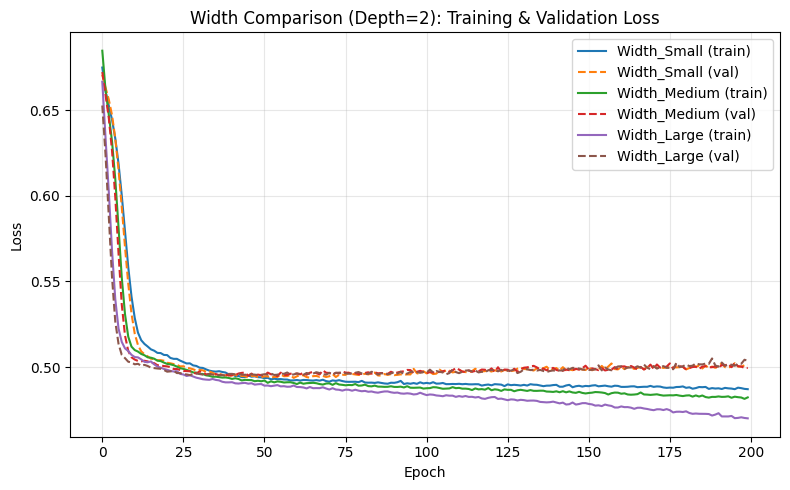

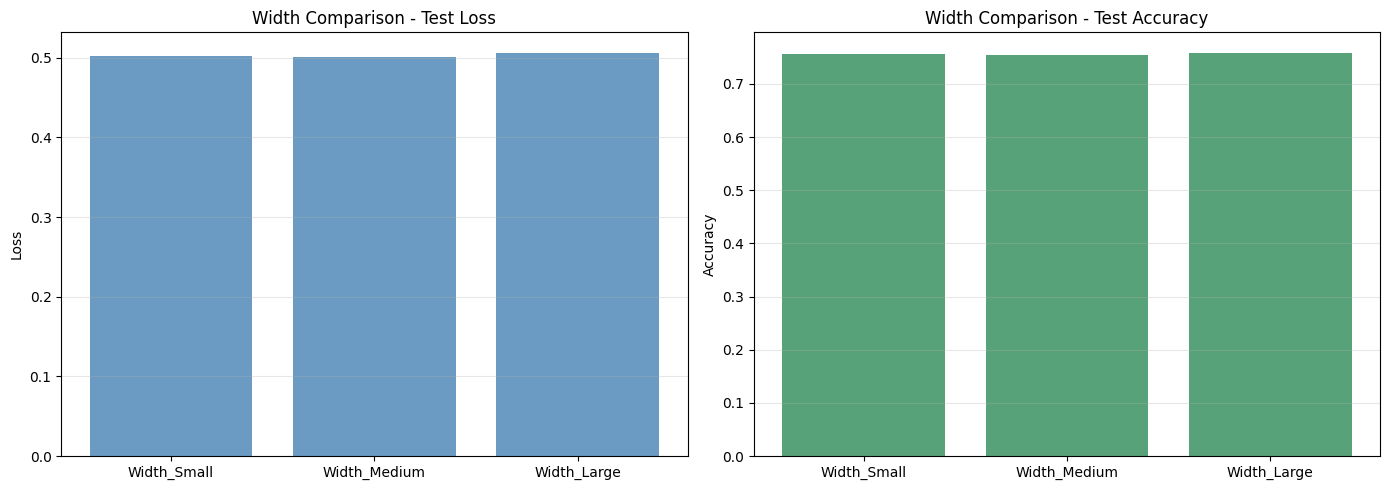

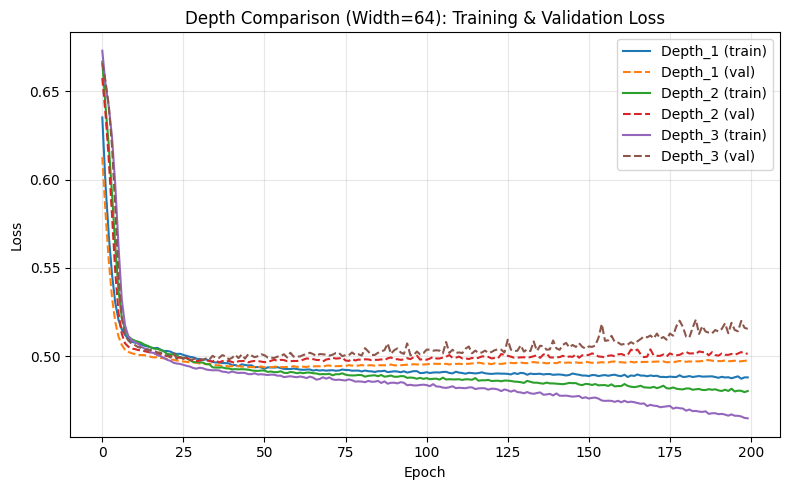

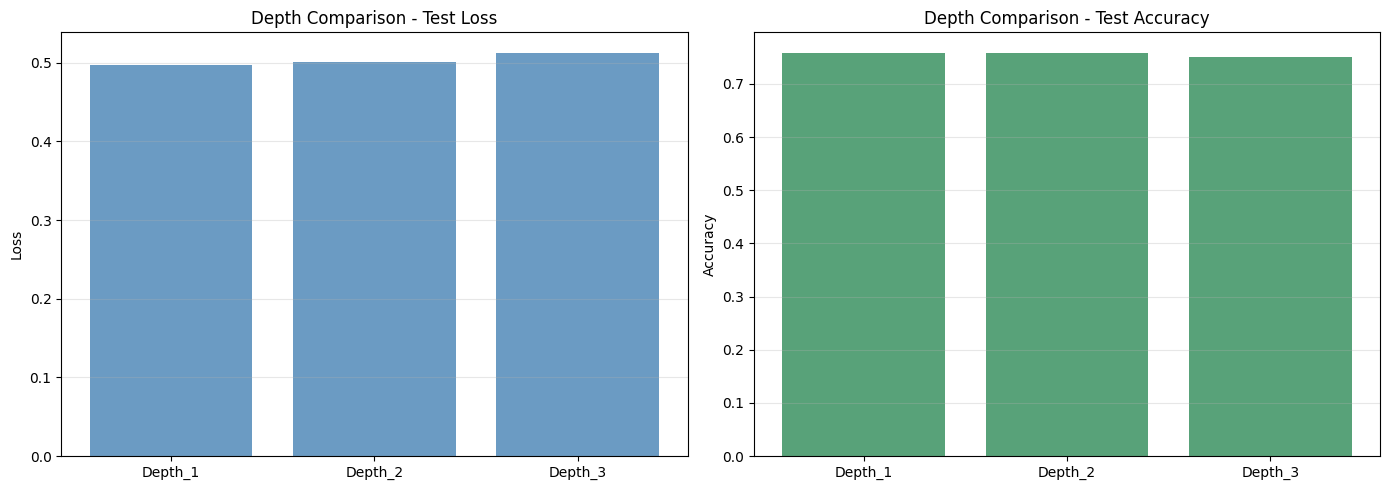

In [9]:
width_results = {k: results[k] for k in ['Width_Small', 'Width_Medium', 'Width_Large']}
depth_results = {k: results[k] for k in ['Depth_1', 'Depth_2', 'Depth_3']}

plot_train_val_curves(
    width_results,
    title='Width Comparison (Depth=2): Training & Validation Loss',
    zoom_start=50,
)
plot_prediction_bars(
    width_results,
    title_prefix='Width Comparison',
)

plot_train_val_curves(
    depth_results,
    title='Depth Comparison (Width=64): Training & Validation Loss',
    zoom_start=50,
)
plot_prediction_bars(
    depth_results,
    title_prefix='Depth Comparison',
)

### 4.1.2 Fungsi Aktivasi

In [10]:
BASE_ARCH = [128, 64]

activation_functions = ['linear', 'relu', 'leaky_relu', 'elu', 'sigmoid', 'tanh']

activation_experiments = {}

for act_name in activation_functions:
    config = []
    
    # Hidden Layer 1
    config.append({
        'n_in': n_features,
        'n_out': BASE_ARCH[0],
        'activation': act_name
    })
    
    # Hidden Layer 2
    config.append({
        'n_in': BASE_ARCH[0],
        'n_out': BASE_ARCH[1],
        'activation': 'relu'
    })
    
    # Output Layer
    config.append({
        'n_in': BASE_ARCH[1],
        'n_out': n_out,
        'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'
    })
    
    exp_suffix = act_name.replace('_', ' ').title().replace(' ', '_')
    activation_experiments[f'Act_{exp_suffix}'] = config

print('Activation Function Experiments:')
for name, config in activation_experiments.items():
    tested_act = config[0]['activation']
    fixed_act = config[1]['activation']
    print(f"  {name}: L1='{tested_act}', L2 fixed='{fixed_act}'")

Activation Function Experiments:
  Act_Linear: L1='linear', L2 fixed='relu'
  Act_Relu: L1='relu', L2 fixed='relu'
  Act_Leaky_Relu: L1='leaky_relu', L2 fixed='relu'
  Act_Elu: L1='elu', L2 fixed='relu'
  Act_Sigmoid: L1='sigmoid', L2 fixed='relu'
  Act_Tanh: L1='tanh', L2 fixed='relu'


In [11]:
INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

activation_results = run_architecture_experiments(
    experiments=activation_experiments,
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init=INIT,
    lr=0.01,
    regularization='l2',
    lambda_=1e-4,
    epochs=200,
    batch_size=32,
    verbose=20,
)


Running: Act_Linear
  Layer 1: DenseLayer(8 → 128, activation=Linear)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch 10/200, Train Loss: 0.5051, Val Loss: 0.4990
Epoch 20/200, Train Loss: 0.4963, Val Loss: 0.4941
Epoch 30/200, Train Loss: 0.4933, Val Loss: 0.4921
Epoch 40/200, Train Loss: 0.4927, Val Loss: 0.4924
Epoch 50/200, Train Loss: 0.4914, Val Loss: 0.4934
Epoch 60/200, Train Loss: 0.4915, Val Loss: 0.4941
Epoch 70/200, Train Loss: 0.4903, Val Loss: 0.4947
Epoch 80/200, Train Loss: 0.4900, Val Loss: 0.4944
Epoch 90/200, Train Loss: 0.4896, Val Loss: 0.4952
Epoch 100/200, Train Loss: 0.4894, Val Loss: 0.4959
Epoch 110/200, Train Loss: 0.4894, Val Loss: 0.4953
Epoch 120/200, Train Loss: 0.4889, Val Loss: 0.4964
Epoch 130/200, Train Loss: 0.4884, Val Loss: 0.4954
Epoch 140/200, Train Loss: 0.4877, Val Loss

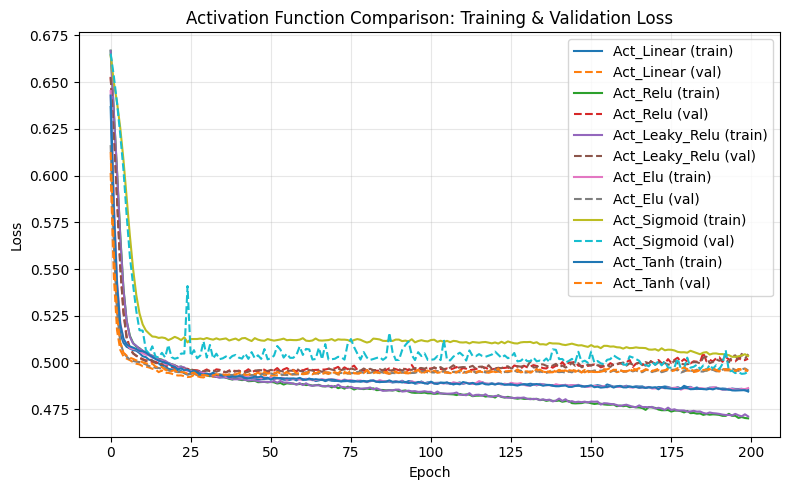

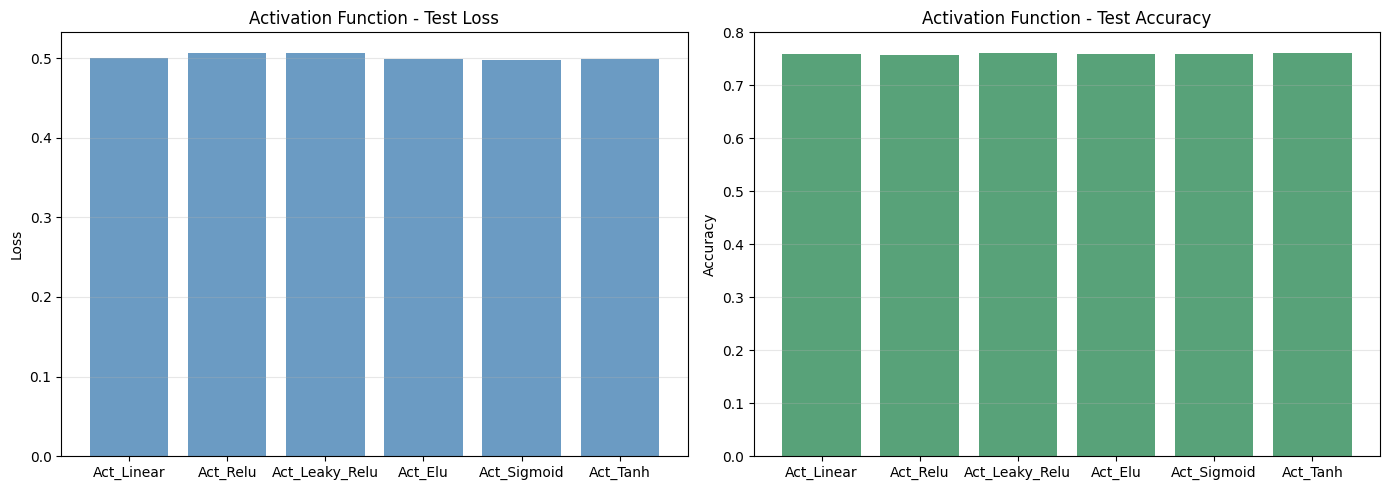

In [12]:
plot_train_val_curves(
    activation_results,
    title='Activation Function Comparison: Training & Validation Loss',
    zoom_start=50,
)

plot_prediction_bars(
    activation_results,
    title_prefix='Activation Function',
)


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Linear
Test Accuracy: 0.7600

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.004746 | Std: 0.112820
  Min: -0.418107 | Max: 0.389086
  Median: -0.001661

Layer 1:
  Shape: (128, 64)
  Mean: -0.000679 | Std: 0.102269
  Min: -0.445684 | Max: 0.407501
  Median: -0.001144

Layer 2:
  Shape: (64, 1)
  Mean: 0.039675 | Std: 0.232351
  Min: -0.443960 | Max: 0.638049
  Median: 0.061363

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000255 | Std: 0.010366
  Min: -0.046642 | Max: 0.038669
  Median: -0.000027
  % Zero Gradients: 0.00%

Layer 1:
  Shape: 

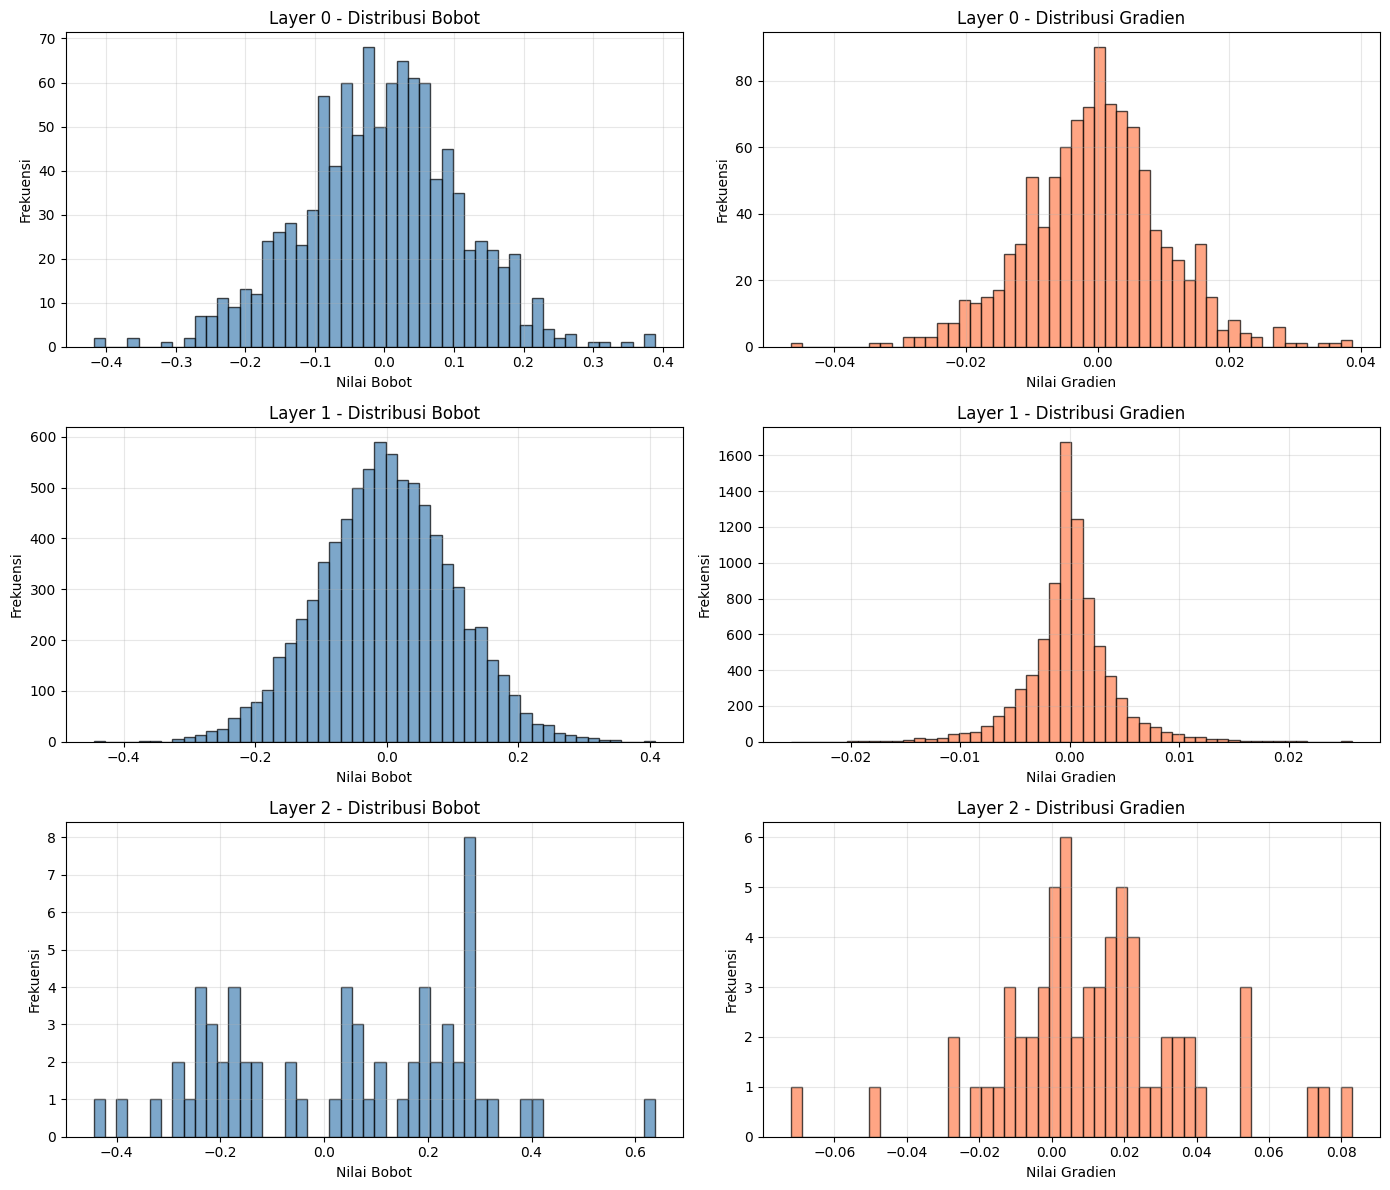


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Relu
Test Accuracy: 0.7575

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001828 | Std: 0.125523
  Min: -0.397970 | Max: 0.548609
  Median: 0.000980

Layer 1:
  Shape: (128, 64)
  Mean: 0.001571 | Std: 0.103971
  Min: -0.438999 | Max: 0.412715
  Median: 0.001664

Layer 2:
  Shape: (64, 1)
  Mean: 0.033024 | Std: 0.310687
  Min: -0.622640 | Max: 0.713647
  Median: 0.030205

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000422 | Std: 0.020660
  Min: -0.081326 | Max: 0.086327
  Median: 0.000207
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (128, 6

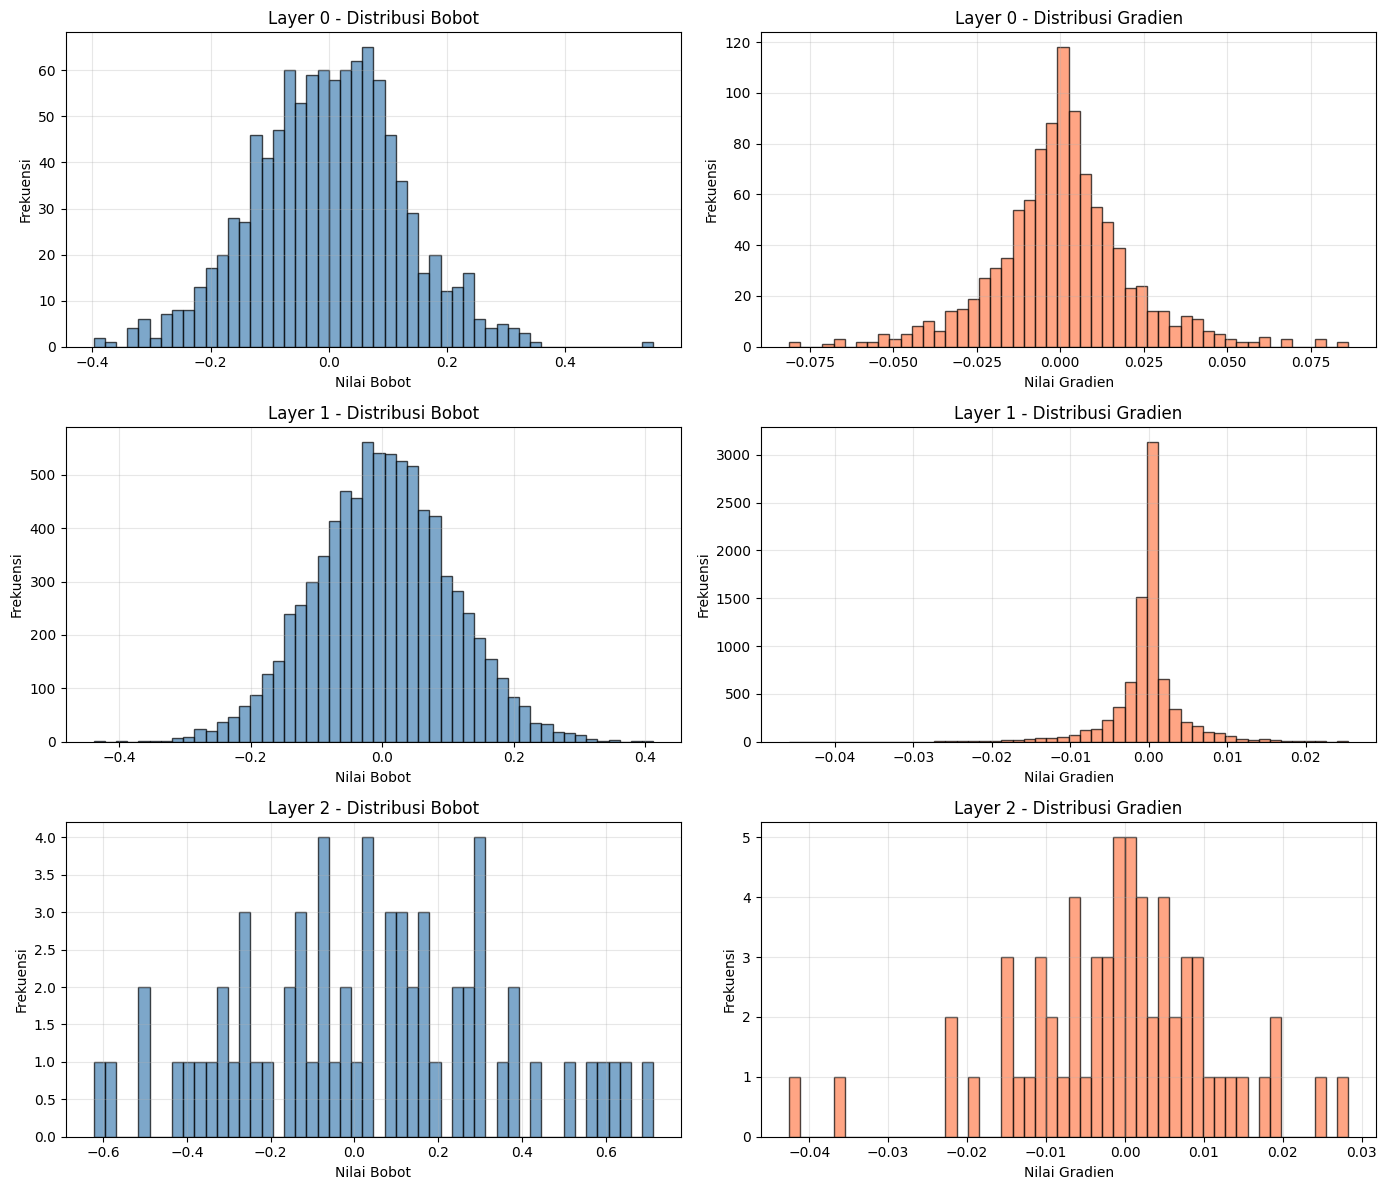


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Leaky_Relu
Test Accuracy: 0.7620

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001802 | Std: 0.124856
  Min: -0.390765 | Max: 0.545260
  Median: 0.003697

Layer 1:
  Shape: (128, 64)
  Mean: 0.001669 | Std: 0.103895
  Min: -0.438216 | Max: 0.421933
  Median: 0.001601

Layer 2:
  Shape: (64, 1)
  Mean: 0.033018 | Std: 0.307754
  Min: -0.607888 | Max: 0.700570
  Median: 0.036584

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000266 | Std: 0.034045
  Min: -0.145621 | Max: 0.153426
  Median: -0.000302
  % Zero Gradients: 0.00%

Layer 1:
  Shape: 

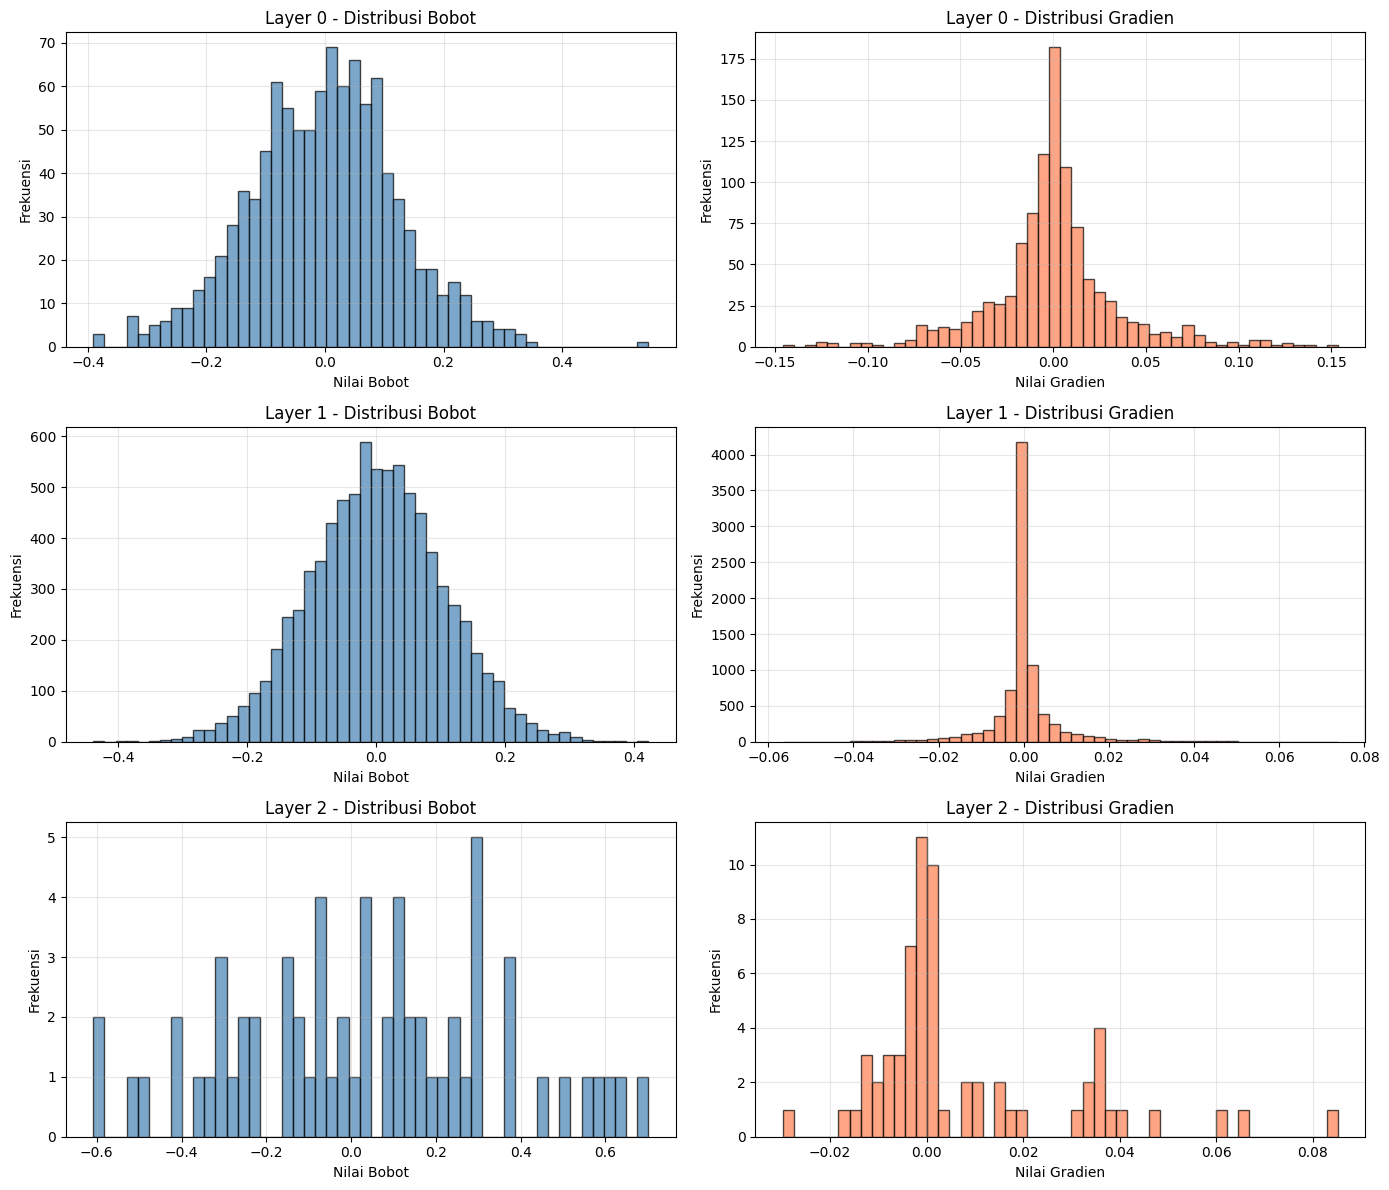


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Elu
Test Accuracy: 0.7595

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.004734 | Std: 0.113383
  Min: -0.408922 | Max: 0.412463
  Median: -0.000305

Layer 1:
  Shape: (128, 64)
  Mean: -0.000291 | Std: 0.102361
  Min: -0.450093 | Max: 0.402348
  Median: -0.000481

Layer 2:
  Shape: (64, 1)
  Mean: 0.046453 | Std: 0.235931
  Min: -0.428048 | Max: 0.637560
  Median: 0.057636

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000541 | Std: 0.025636
  Min: -0.095584 | Max: 0.117127
  Median: -0.000296
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (12

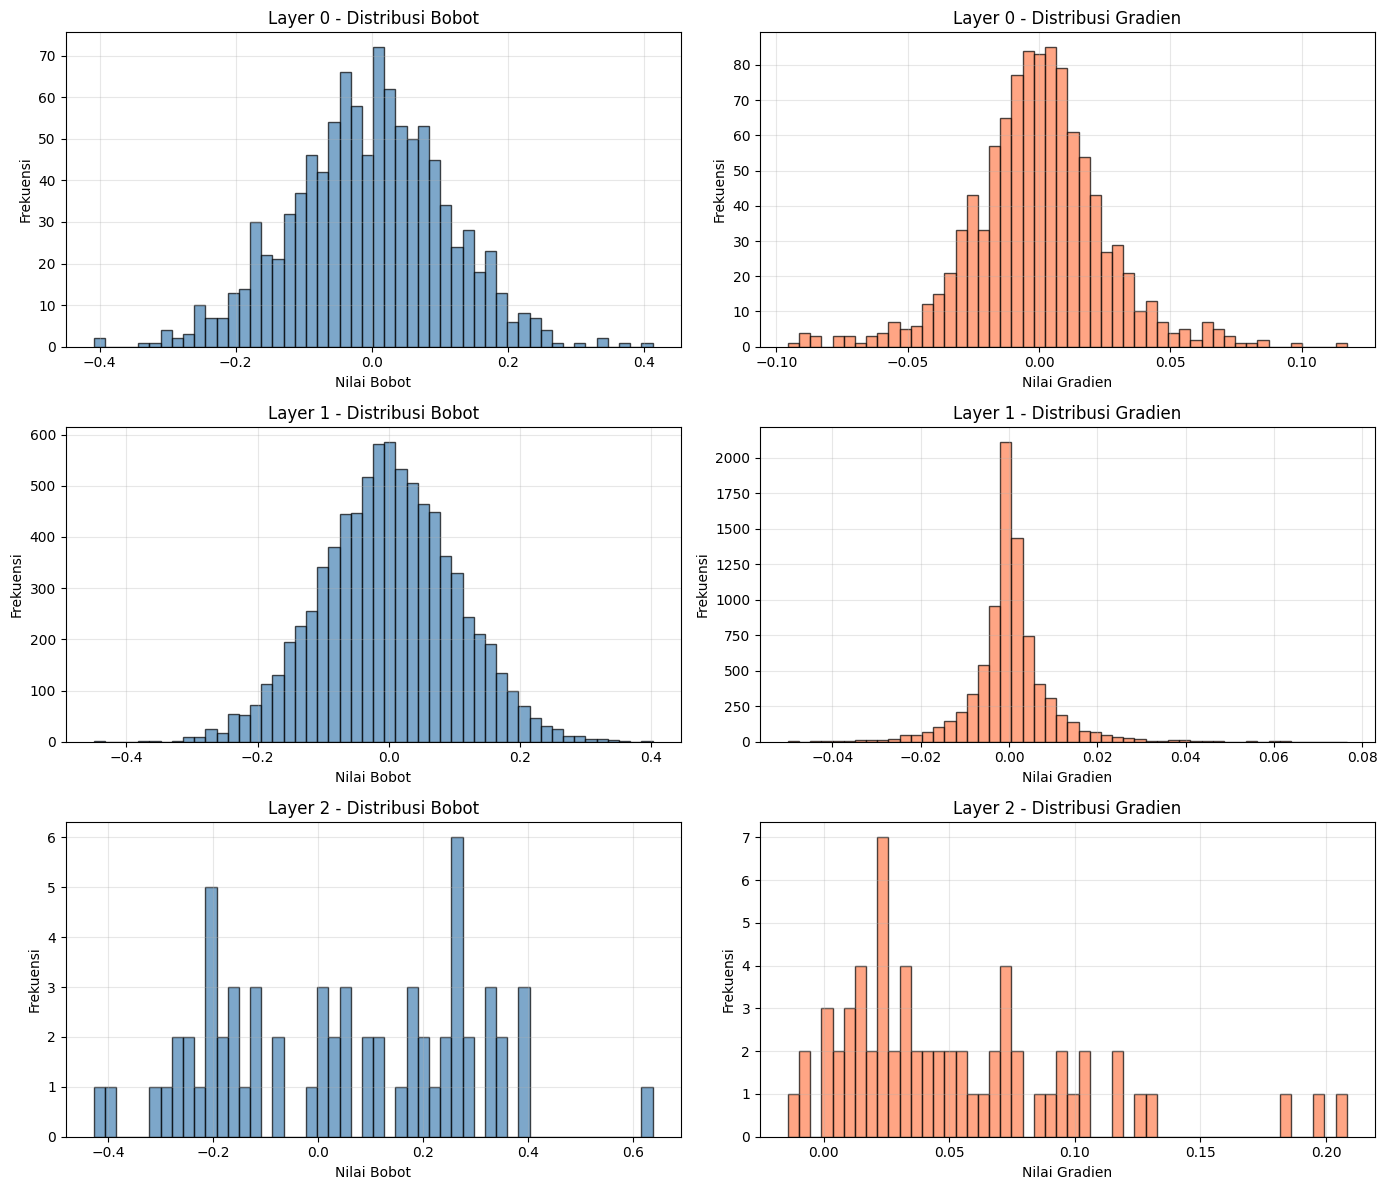


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Sigmoid
Test Accuracy: 0.7585

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.002129 | Std: 0.116093
  Min: -0.384319 | Max: 0.409078
  Median: 0.002170

Layer 1:
  Shape: (128, 64)
  Mean: 0.000140 | Std: 0.102775
  Min: -0.438911 | Max: 0.436835
  Median: 0.000381

Layer 2:
  Shape: (64, 1)
  Mean: 0.026331 | Std: 0.223003
  Min: -0.411957 | Max: 1.015334
  Median: 0.012226

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000062 | Std: 0.007136
  Min: -0.033303 | Max: 0.041167
  Median: -0.000058
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (1

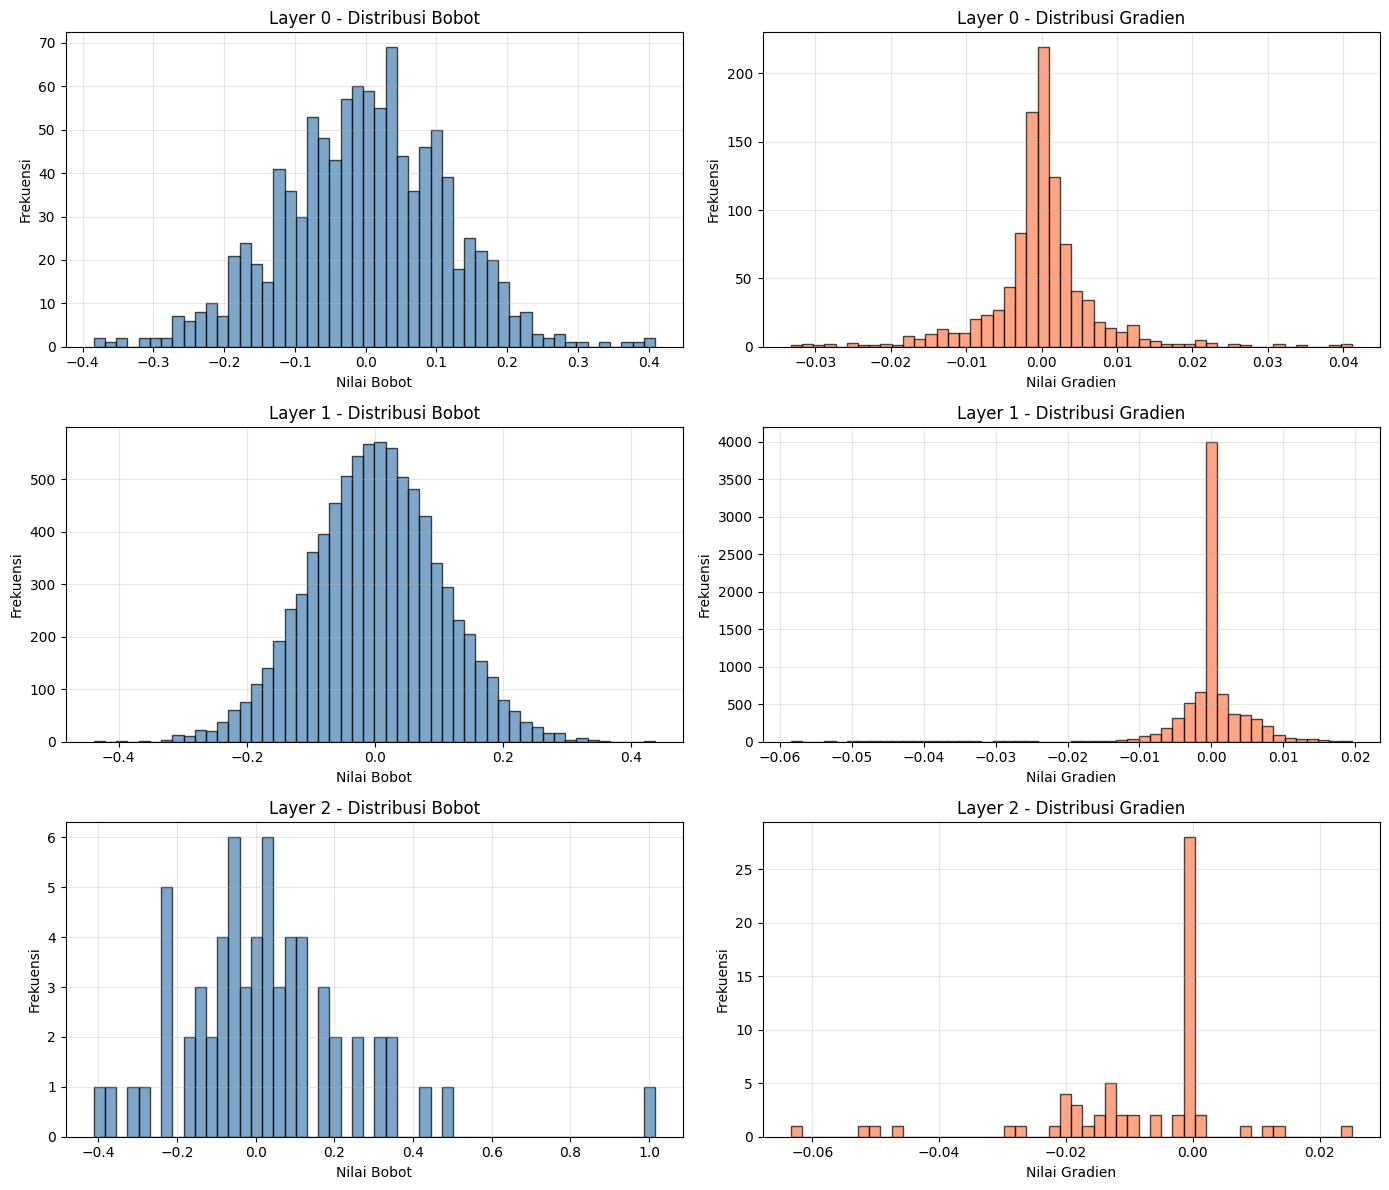


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Tanh
Test Accuracy: 0.7615

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.004449 | Std: 0.113408
  Min: -0.397067 | Max: 0.414867
  Median: 0.000000

Layer 1:
  Shape: (128, 64)
  Mean: -0.000872 | Std: 0.102392
  Min: -0.453792 | Max: 0.398849
  Median: -0.001001

Layer 2:
  Shape: (64, 1)
  Mean: 0.043237 | Std: 0.239285
  Min: -0.466360 | Max: 0.643406
  Median: 0.058881

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000115 | Std: 0.009758
  Min: -0.052741 | Max: 0.045347
  Median: -0.000022
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (12

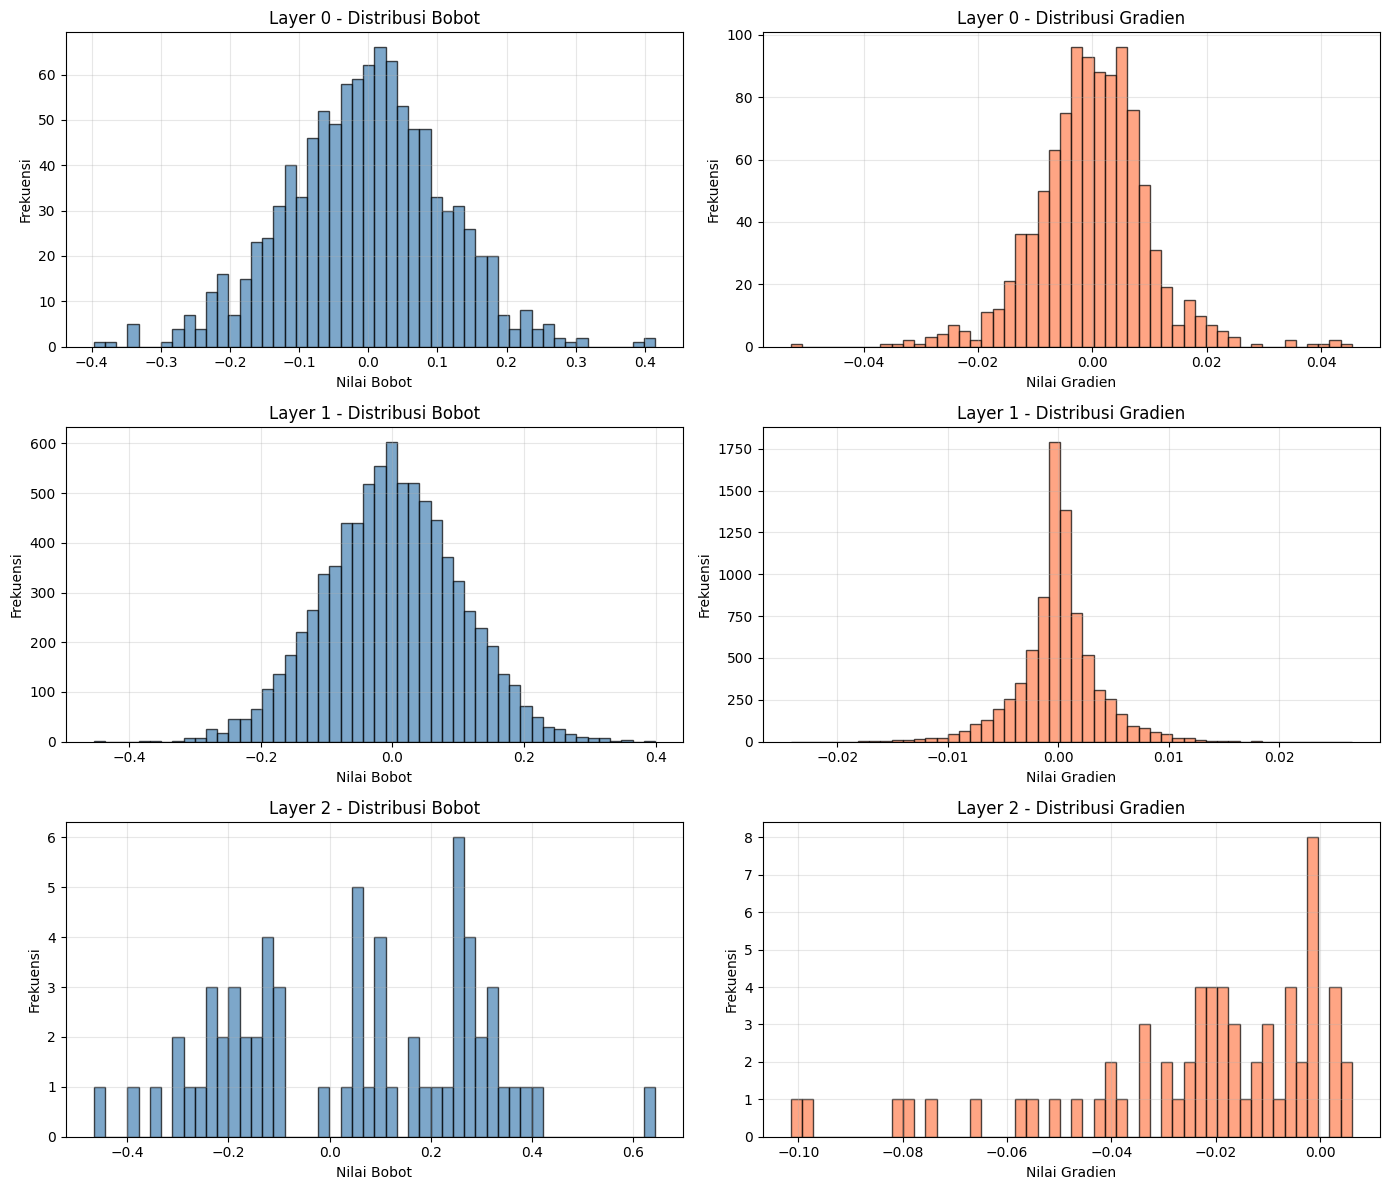

In [13]:
analyze_results_distributions(
    activation_results,
    result_group_name='Activation',
)

### 4.1.3 Learning Rate

In [14]:
learning_rates = {
    'LR_0.001': 0.001,
    'LR_0.01': 0.01,
    'LR_0.1': 0.1,
}

BASE_LR_ARCH = [
    {'n_in': n_features, 'n_out': 128, 'activation': 'relu'},
    {'n_in': 128, 'n_out': 64, 'activation': 'relu'},
    {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
]

INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

lr_results = run_learning_rate_experiments(
    learning_rates=learning_rates,
    base_arch=BASE_LR_ARCH,
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init=INIT,
    regularization='l2',
    lambda_=1e-4,
    epochs=200,
    batch_size=32,
    verbose=20,
)


Running: LR_0.001 (lr=0.001)
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch 10/200, Train Loss: 0.5074, Val Loss: 0.5033
Epoch 20/200, Train Loss: 0.4990, Val Loss: 0.4982
Epoch 30/200, Train Loss: 0.4941, Val Loss: 0.4965
Epoch 40/200, Train Loss: 0.4907, Val Loss: 0.4955
Epoch 50/200, Train Loss: 0.4900, Val Loss: 0.4959
Epoch 60/200, Train Loss: 0.4881, Val Loss: 0.4965
Epoch 70/200, Train Loss: 0.4871, Val Loss: 0.4958
Epoch 80/200, Train Loss: 0.4858, Val Loss: 0.4960
Epoch 90/200, Train Loss: 0.4852, Val Loss: 0.4962
Epoch 100/200, Train Loss: 0.4844, Val Loss: 0.4978
Epoch 110/200, Train Loss: 0.4831, Val Loss: 0.4965
Epoch 120/200, Train Loss: 0.4814, Val Loss: 0.4972
Epoch 130/200, Train Loss: 0.4807, Val Loss: 0.4972
Epoch 140/200, Train Loss: 0.4800, V

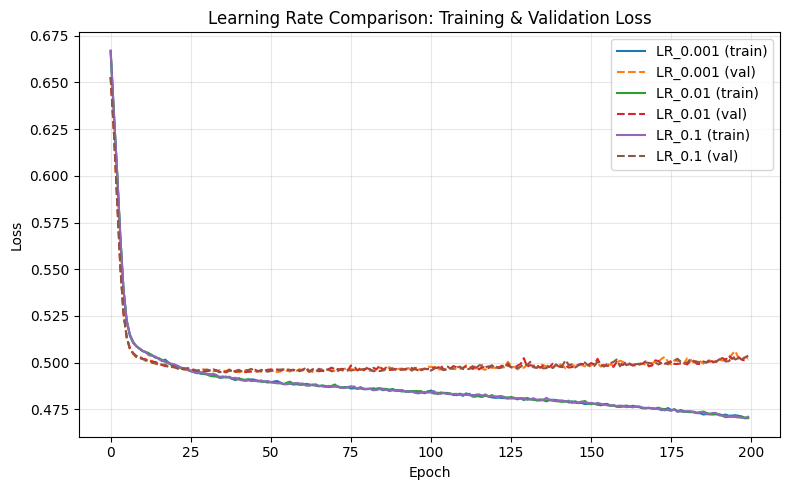

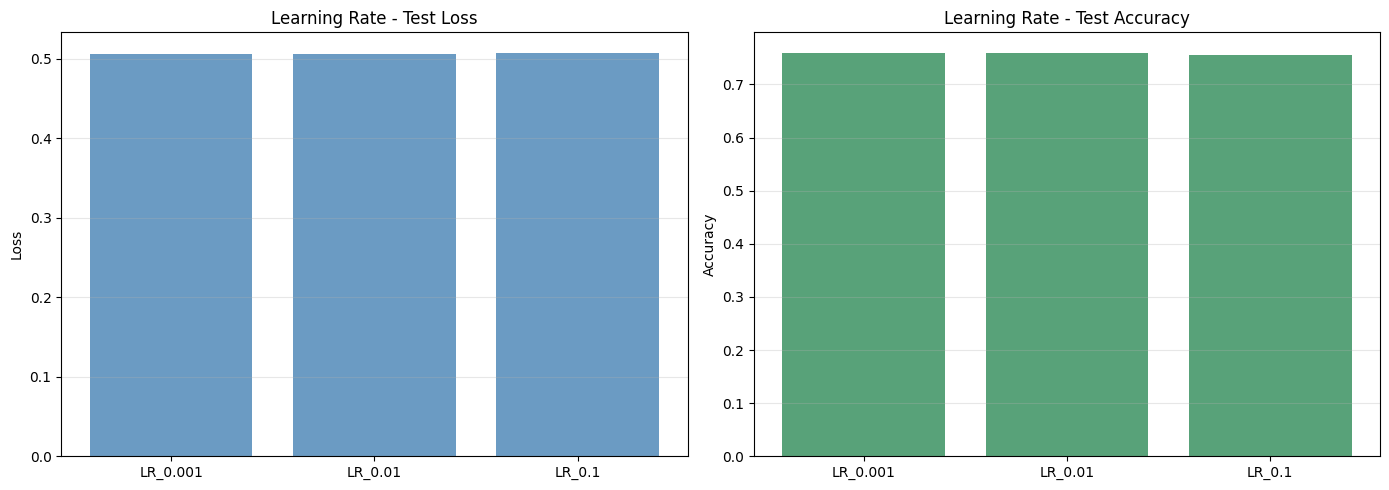

In [15]:
plot_train_val_curves(
    lr_results,
    title='Learning Rate Comparison: Training & Validation Loss',
    zoom_start=50,
)

plot_prediction_bars(
    lr_results,
    title_prefix='Learning Rate',
)


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Learning Rate
Model: LR_0.001
Test Accuracy: 0.7595

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001765 | Std: 0.125172
  Min: -0.392011 | Max: 0.547161
  Median: 0.001044

Layer 1:
  Shape: (128, 64)
  Mean: 0.001548 | Std: 0.103942
  Min: -0.438942 | Max: 0.416399
  Median: 0.001737

Layer 2:
  Shape: (64, 1)
  Mean: 0.032245 | Std: 0.309421
  Min: -0.613042 | Max: 0.709474
  Median: 0.034342

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000085 | Std: 0.025707
  Min: -0.144803 | Max: 0.117179
  Median: -0.000051
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (1

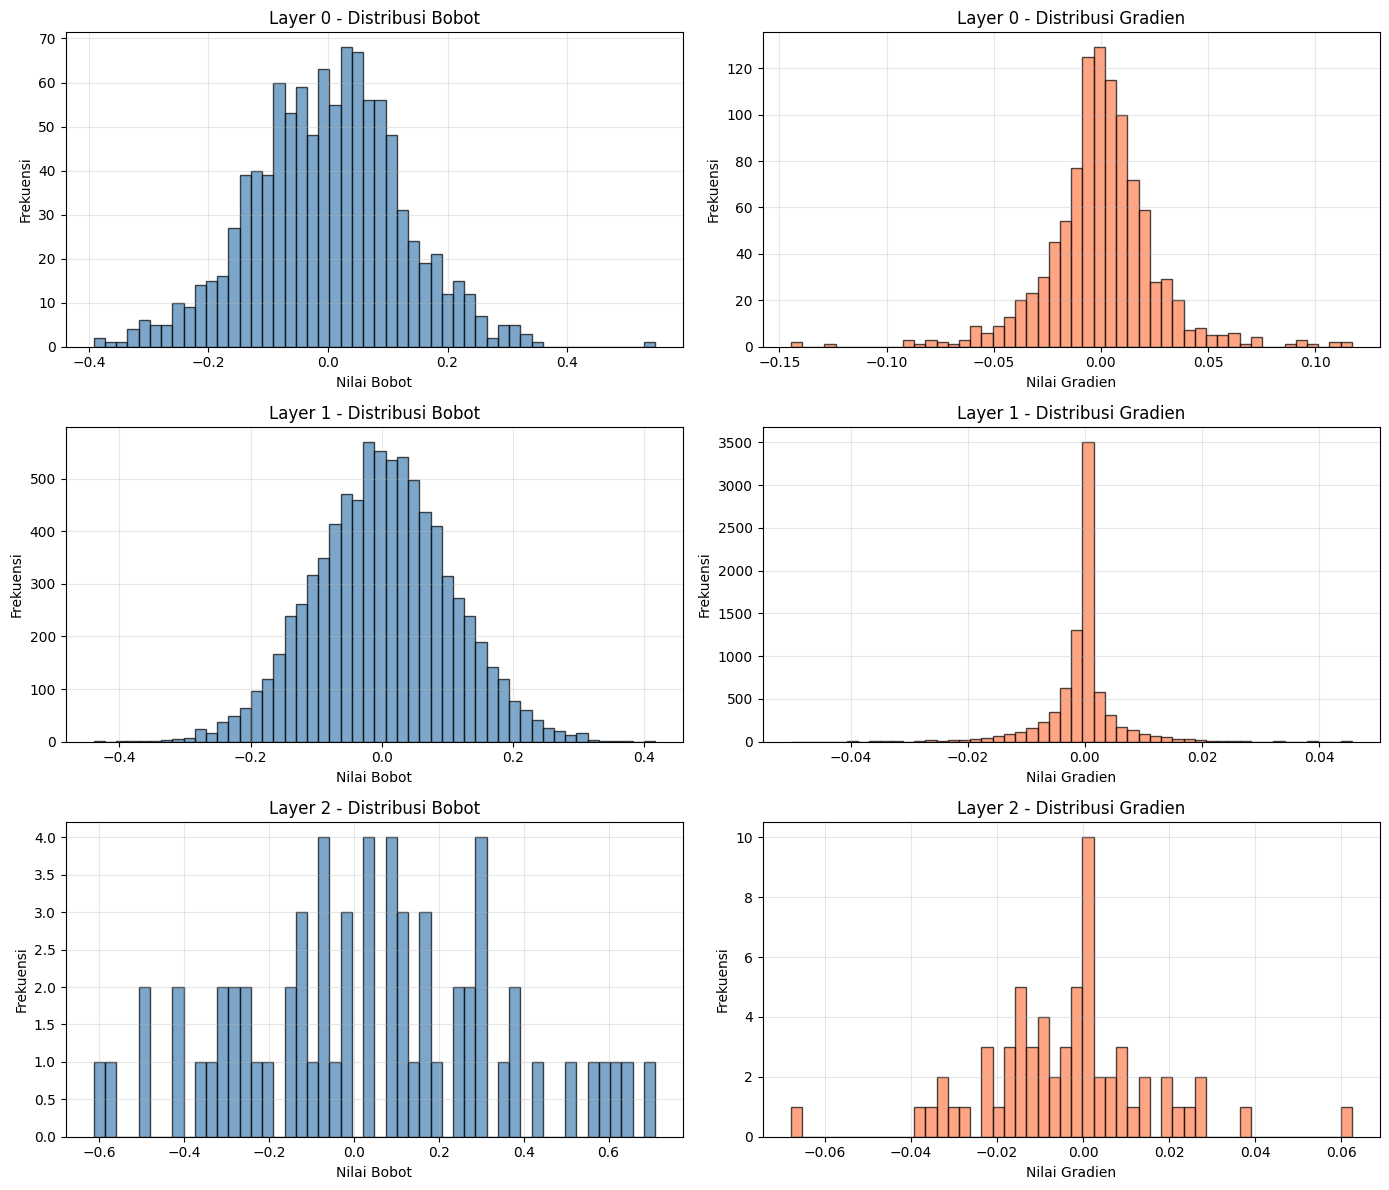


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Learning Rate
Model: LR_0.01
Test Accuracy: 0.7600

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001979 | Std: 0.125351
  Min: -0.400067 | Max: 0.544511
  Median: 0.001745

Layer 1:
  Shape: (128, 64)
  Mean: 0.001623 | Std: 0.103954
  Min: -0.438944 | Max: 0.412826
  Median: 0.001808

Layer 2:
  Shape: (64, 1)
  Mean: 0.032609 | Std: 0.309983
  Min: -0.614595 | Max: 0.709964
  Median: 0.033467

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000550 | Std: 0.023286
  Min: -0.104125 | Max: 0.097991
  Median: -0.000535
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (12

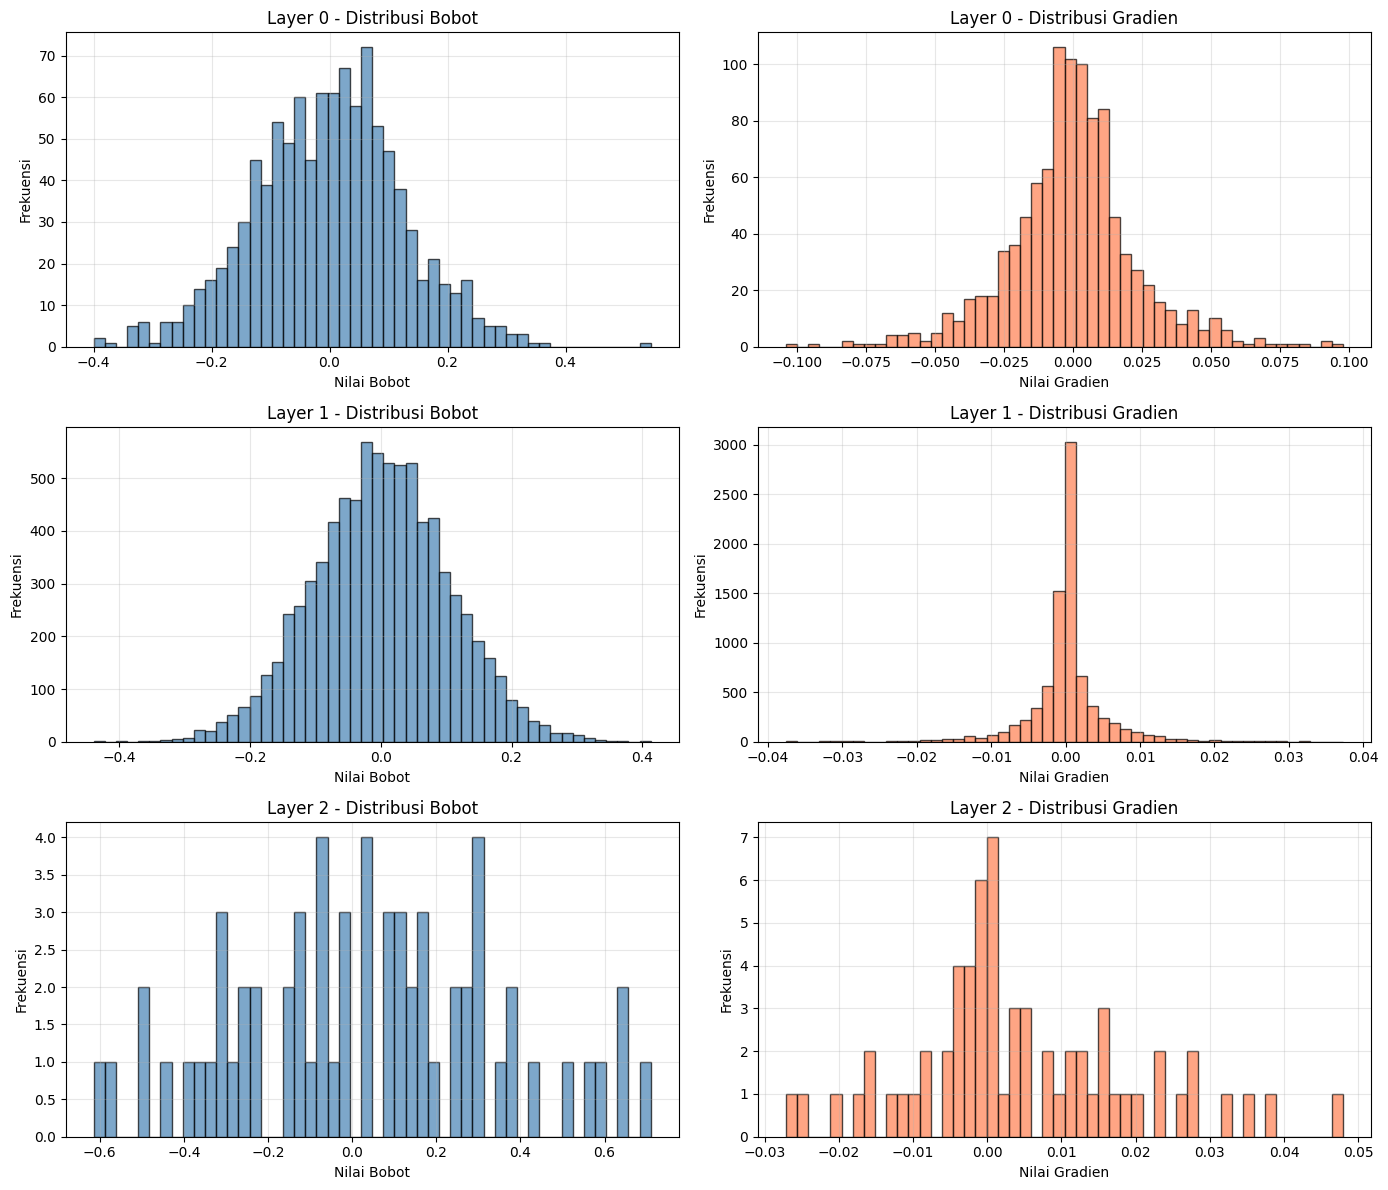


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Learning Rate
Model: LR_0.1
Test Accuracy: 0.7555

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001567 | Std: 0.125268
  Min: -0.396509 | Max: 0.548173
  Median: 0.000638

Layer 1:
  Shape: (128, 64)
  Mean: 0.001592 | Std: 0.103953
  Min: -0.438147 | Max: 0.419213
  Median: 0.001650

Layer 2:
  Shape: (64, 1)
  Mean: 0.033148 | Std: 0.309958
  Min: -0.614186 | Max: 0.705426
  Median: 0.032559

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000507 | Std: 0.032397
  Min: -0.130567 | Max: 0.149677
  Median: -0.000038
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (128

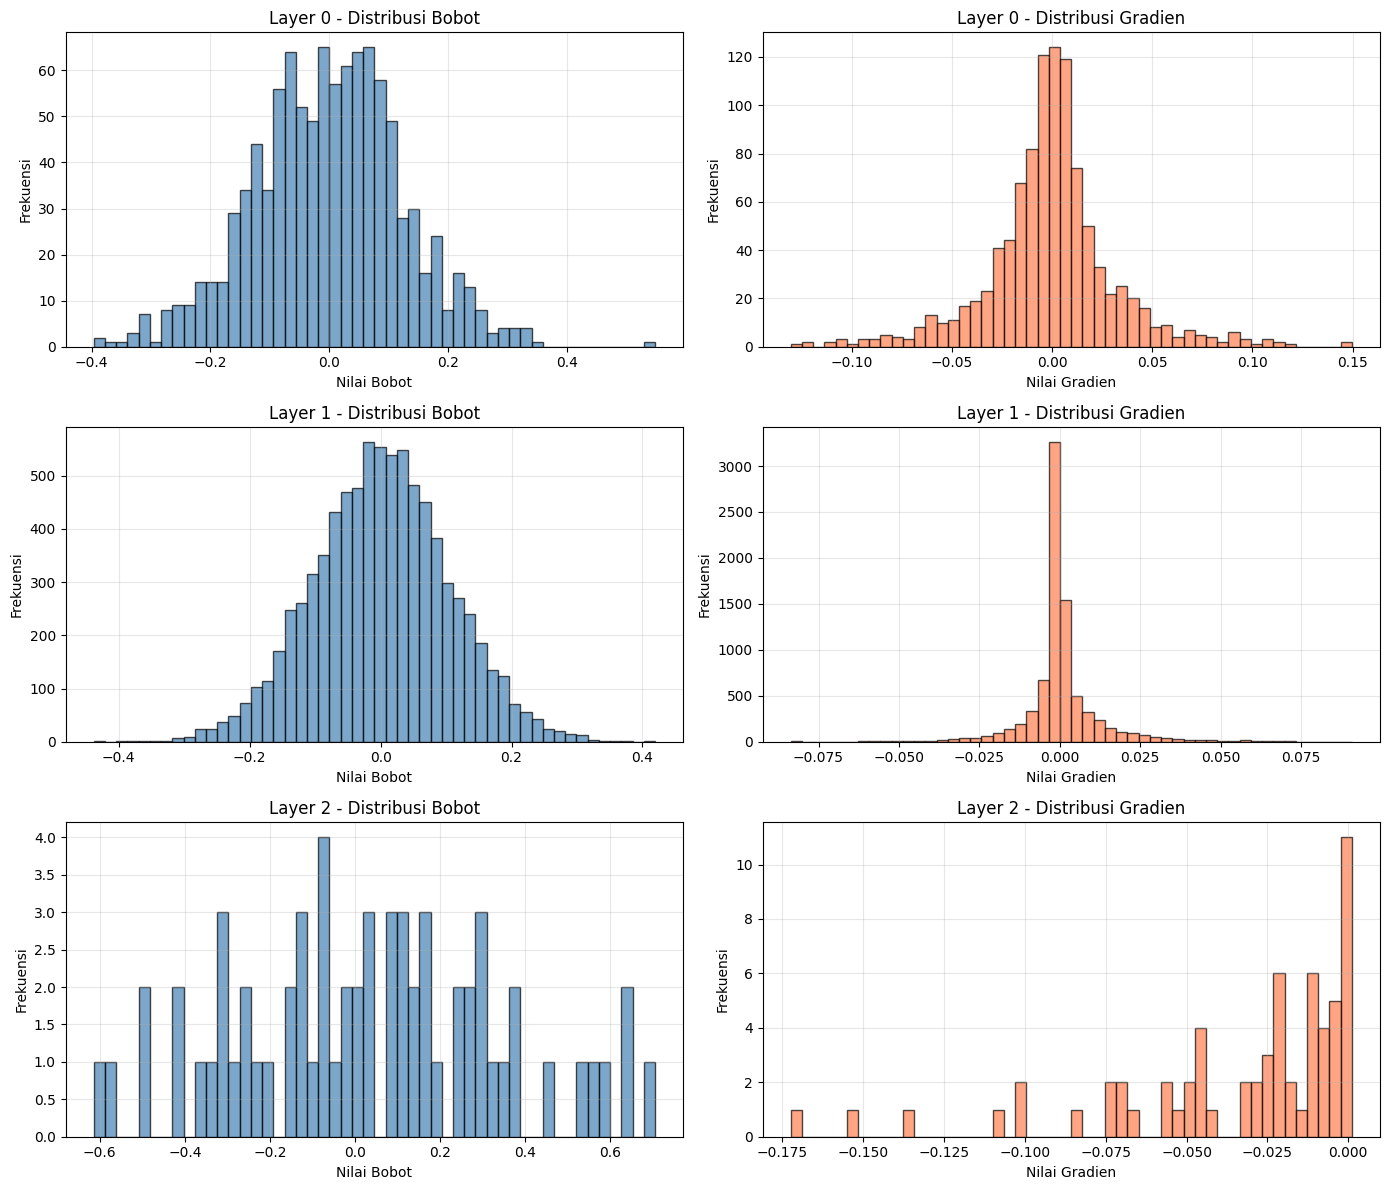

In [16]:
analyze_results_distributions(
    lr_results,
    result_group_name='Learning Rate',
)

### 4.1.4 Pengaruh Inisialisasi Bobot

Memulai Eksperimen Inisialisasi Bobot...

Menguji Inisialisasi: ZERO

Running: zero
  Layer 1: DenseLayer(8 → 64, activation=ReLU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

zero - Test Loss: 0.6678, Accuracy: 0.6125

Menguji Inisialisasi: RANDOM_UNIFORM

Running: random_uniform
  Layer 1: DenseLayer(8 → 64, activation=ReLU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

random_uniform - Test Loss: 0.5036, Accuracy: 0.7555

Menguji Inisialisasi: RANDOM_NORMAL

Running: random_normal
  Layer 1: DenseLayer(8 → 64, activation=ReLU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

random_normal - Test Loss: 0.5207, Accuracy: 0.7420


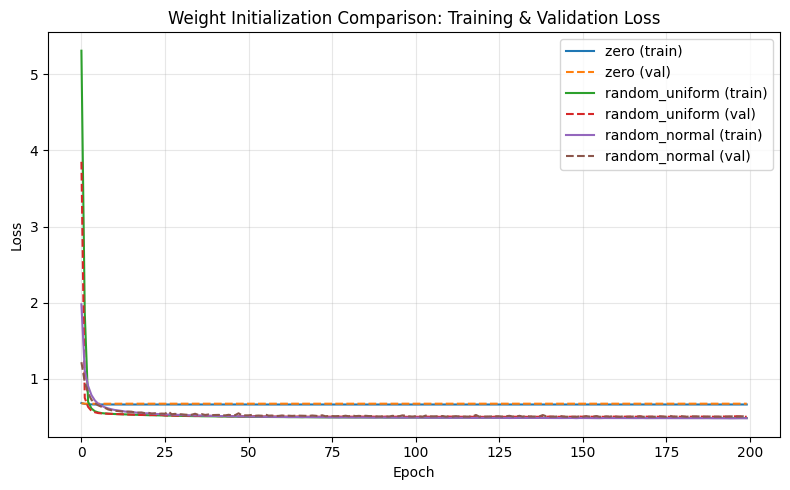

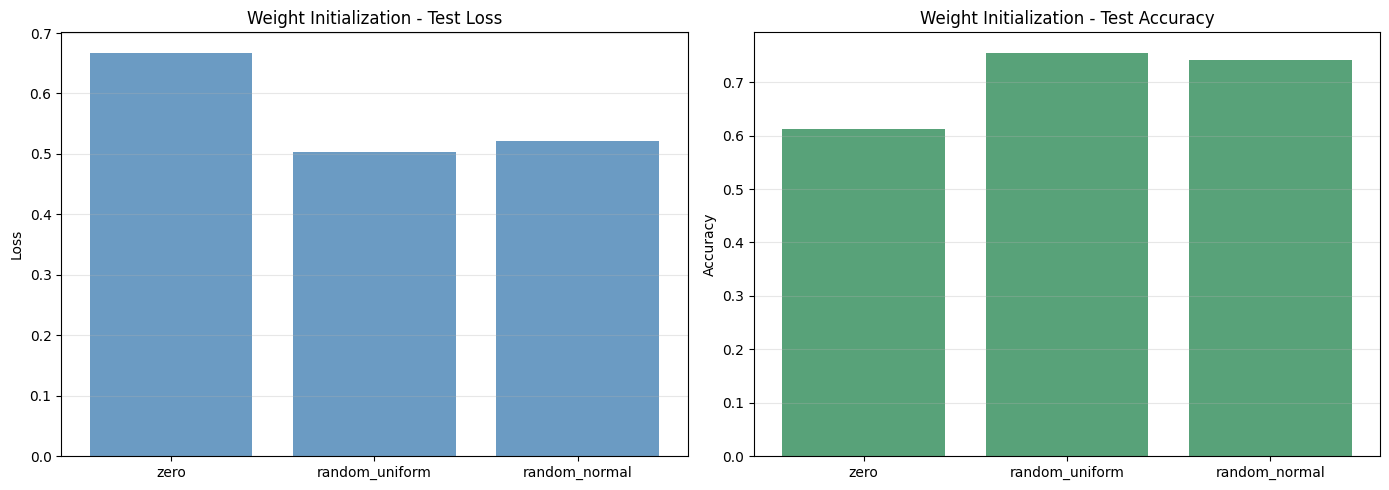

In [17]:
print("Memulai Eksperimen Inisialisasi Bobot...")

init_methods = ['zero', 'random_uniform', 'random_normal']
init_results = {}

output_activation = 'softmax' if TASK == 'multiclass' else 'sigmoid'
arch_for_init = [
    {'n_in': n_features, 'n_out': 64, 'activation': 'relu'},
    {'n_in': 64, 'n_out': n_out, 'activation': output_activation},
]

for method in init_methods:
    print(f"\n{'=' * 60}")
    print(f"Menguji Inisialisasi: {method.upper()}")
    print(f"{'=' * 60}")

    temp_exp = {method: arch_for_init}
    init_dict = {'init_method': method}

    res = run_architecture_experiments(
        experiments=temp_exp,
        task=TASK,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test,
        init=init_dict,
        lr=0.01,
        regularization='none',
        epochs=200,
        batch_size=32,
        verbose=0,
    )

    init_results[method] = res[method]

plot_train_val_curves(
    init_results,
    title='Weight Initialization Comparison: Training & Validation Loss',
)

plot_prediction_bars(
    init_results,
    title_prefix='Weight Initialization',
)

## 4.2 Pengaruh Regularisasi


Running: Reg_None
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch 10/200, Train Loss: 0.5077, Val Loss: 0.5024
Epoch 20/200, Train Loss: 0.4991, Val Loss: 0.4971
Epoch 30/200, Train Loss: 0.4940, Val Loss: 0.4958
Epoch 40/200, Train Loss: 0.4912, Val Loss: 0.4948
Epoch 50/200, Train Loss: 0.4897, Val Loss: 0.4959
Epoch 60/200, Train Loss: 0.4882, Val Loss: 0.4956
Epoch 70/200, Train Loss: 0.4876, Val Loss: 0.4961
Epoch 80/200, Train Loss: 0.4856, Val Loss: 0.4965
Epoch 90/200, Train Loss: 0.4855, Val Loss: 0.4957
Epoch 100/200, Train Loss: 0.4842, Val Loss: 0.4963
Epoch 110/200, Train Loss: 0.4827, Val Loss: 0.4964
Epoch 120/200, Train Loss: 0.4820, Val Loss: 0.4971
Epoch 130/200, Train Loss: 0.4814, Val Loss: 0.4963
Epoch 140/200, Train Loss: 0.4797, Val Loss: 0.

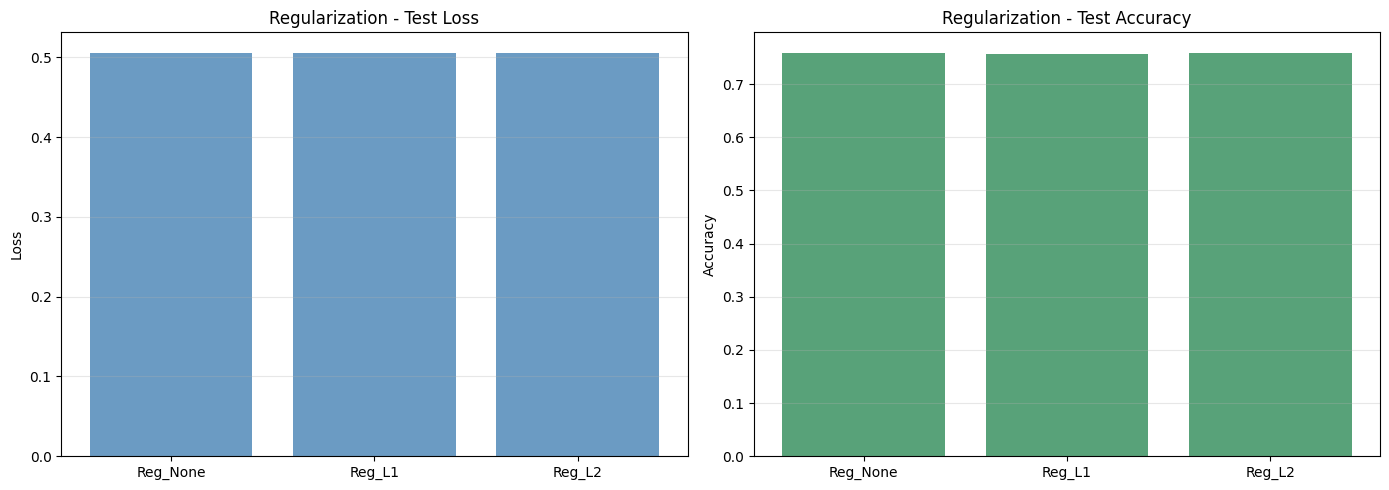

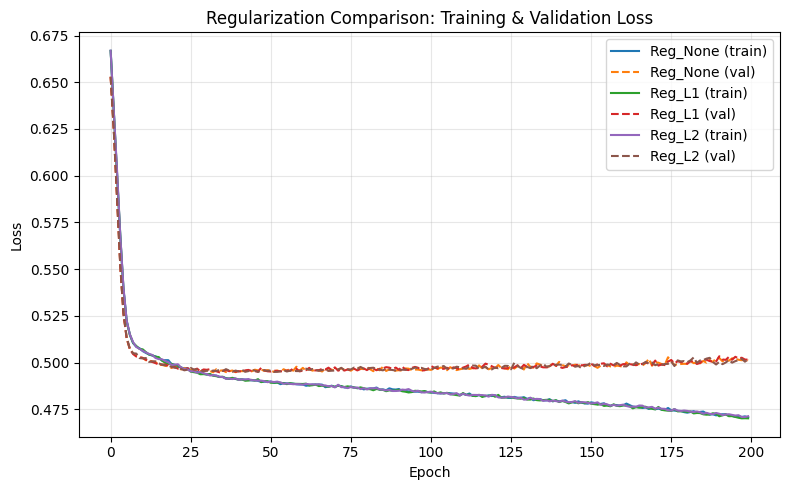


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Regularization
Model: Reg_None
Test Accuracy: 0.7585

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001484 | Std: 0.125104
  Min: -0.392844 | Max: 0.548203
  Median: 0.001876

Layer 1:
  Shape: (128, 64)
  Mean: 0.001549 | Std: 0.103911
  Min: -0.439271 | Max: 0.413470
  Median: 0.001851

Layer 2:
  Shape: (64, 1)
  Mean: 0.031303 | Std: 0.308357
  Min: -0.623478 | Max: 0.699752
  Median: 0.036666

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000005 | Std: 0.021933
  Min: -0.105460 | Max: 0.091810
  Median: -0.000021
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (

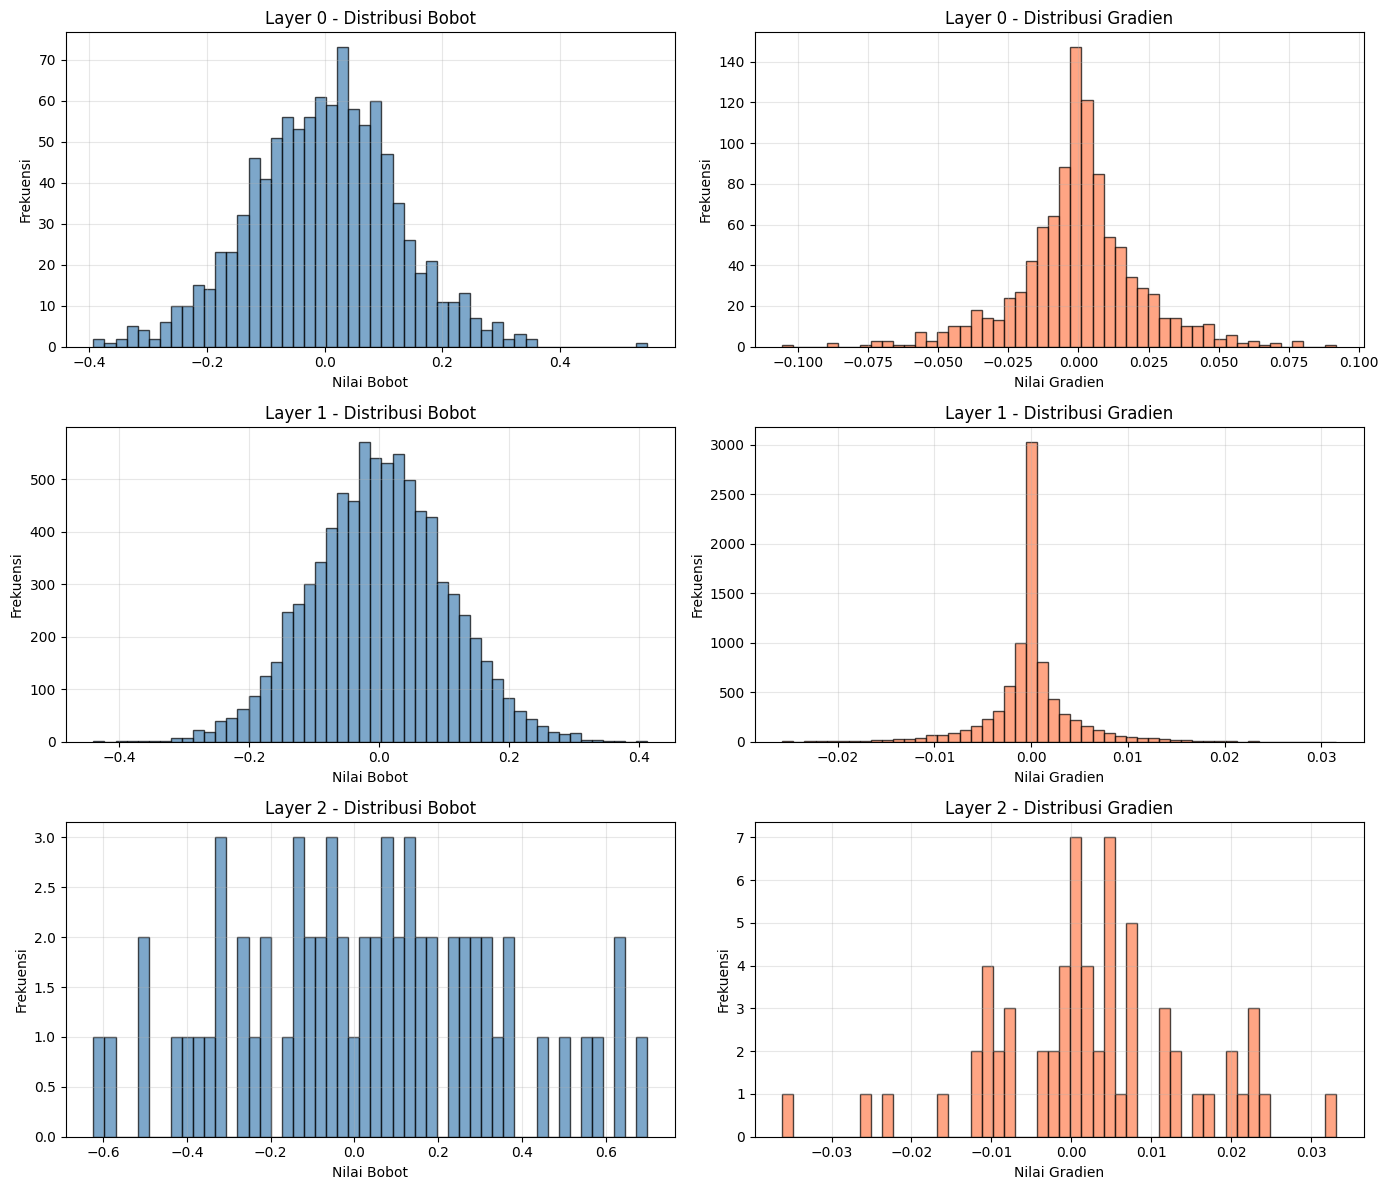


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Regularization
Model: Reg_L1
Test Accuracy: 0.7575

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001802 | Std: 0.125435
  Min: -0.402133 | Max: 0.546834
  Median: 0.003879

Layer 1:
  Shape: (128, 64)
  Mean: 0.001638 | Std: 0.103977
  Min: -0.439237 | Max: 0.418091
  Median: 0.001719

Layer 2:
  Shape: (64, 1)
  Mean: 0.033120 | Std: 0.310885
  Min: -0.625105 | Max: 0.713237
  Median: 0.029661

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001207 | Std: 0.017615
  Min: -0.093890 | Max: 0.073097
  Median: -0.001047
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (12

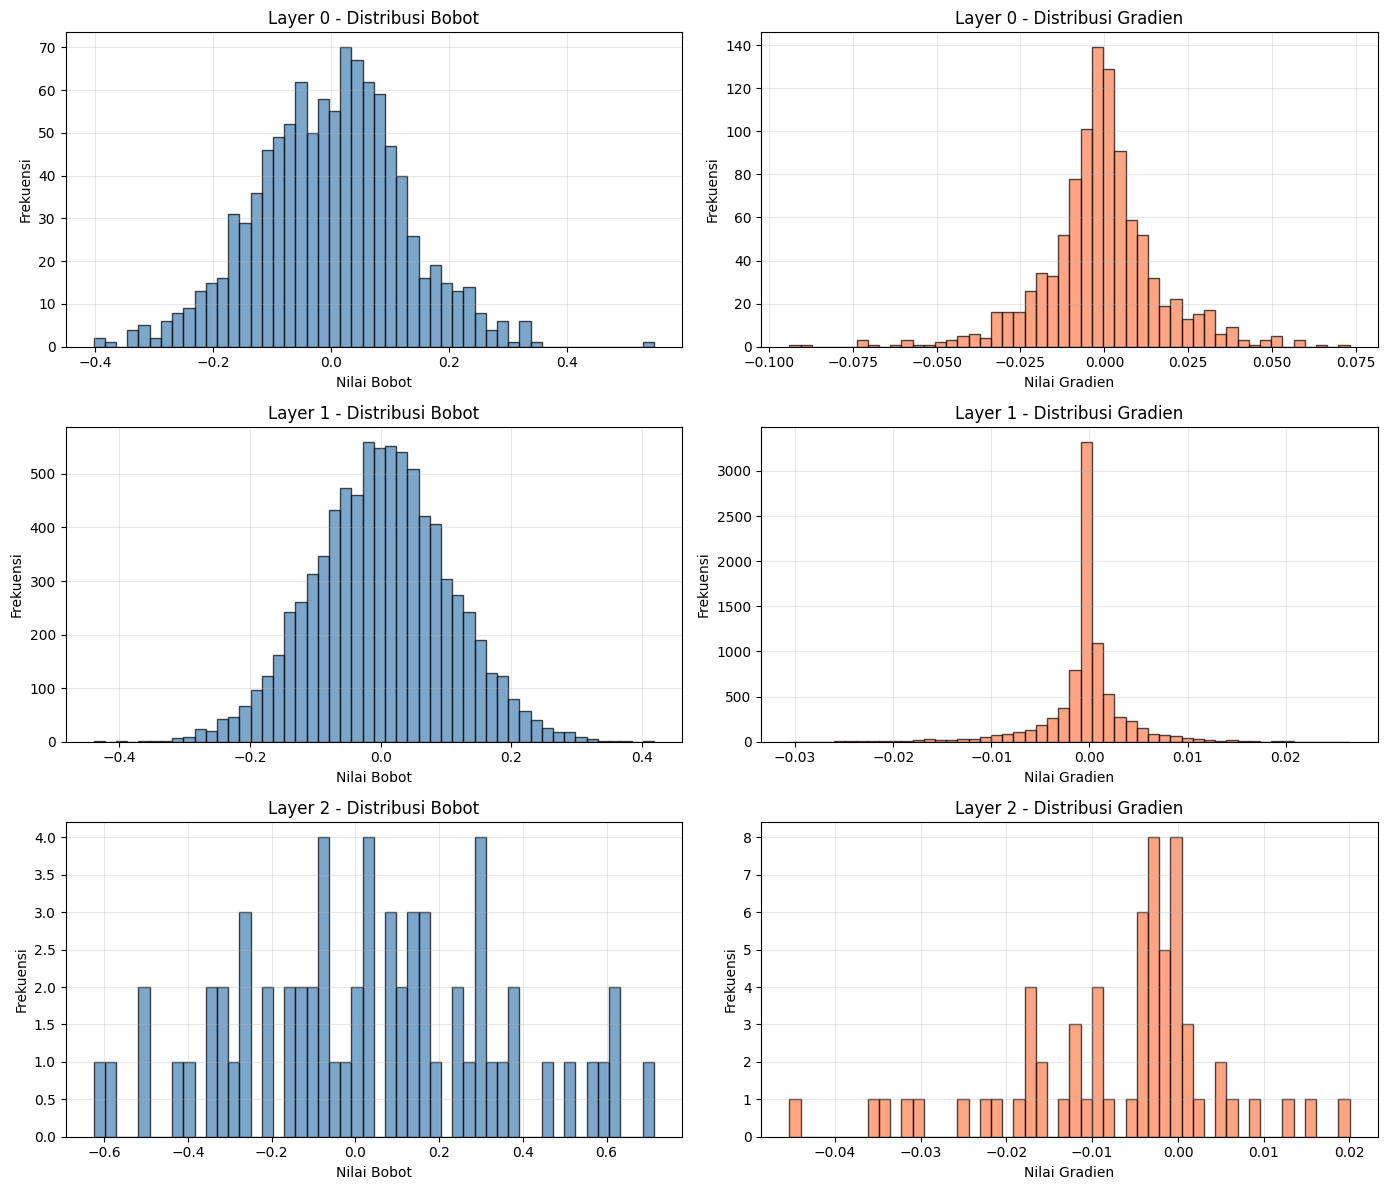


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Regularization
Model: Reg_L2
Test Accuracy: 0.7595

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001747 | Std: 0.125205
  Min: -0.393535 | Max: 0.543138
  Median: 0.003230

Layer 1:
  Shape: (128, 64)
  Mean: 0.001591 | Std: 0.103916
  Min: -0.438197 | Max: 0.414070
  Median: 0.001506

Layer 2:
  Shape: (64, 1)
  Mean: 0.032062 | Std: 0.308502
  Min: -0.617790 | Max: 0.696601
  Median: 0.036727

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000229 | Std: 0.027563
  Min: -0.138204 | Max: 0.120397
  Median: -0.000115
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (12

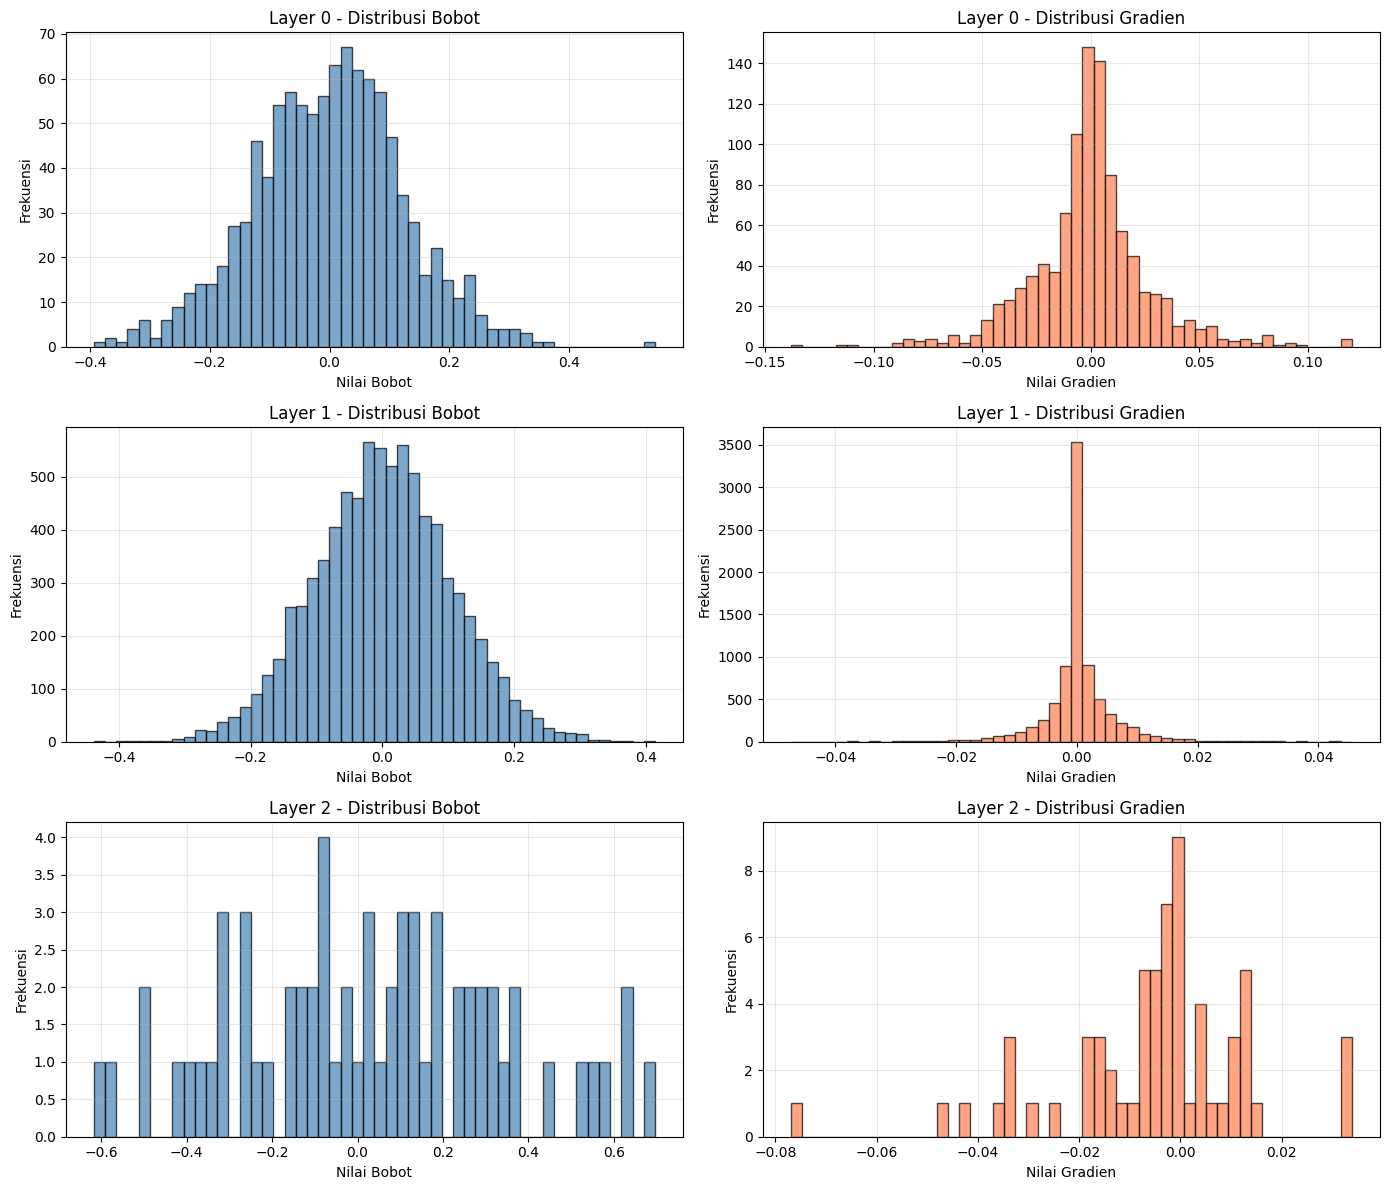

In [ ]:
regularization_settings = {
    'Reg_None': {'regularization': 'none', 'lambda_': 0.0},
    'Reg_L1': {'regularization': 'l1', 'lambda_': 1e-4},
    'Reg_L2': {'regularization': 'l2', 'lambda_': 1e-4},
}

REG_ARCH = [
    {'n_in': n_features, 'n_out': 128, 'activation': 'relu'},
    {'n_in': 128, 'n_out': 64, 'activation': 'relu'},
    {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
]

INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

regularization_results = {}

for exp_name, cfg in regularization_settings.items():
    one_exp = {exp_name: REG_ARCH}

    res = run_architecture_experiments(
        experiments=one_exp,
        task=TASK,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test,
        init=INIT,
        lr=0.01,
        regularization=cfg['regularization'],
        lambda_=cfg['lambda_'],
        epochs=200,
        batch_size=32,
        verbose=20,
    )

    for k, v in res.items():
        v['regularization'] = cfg['regularization']
        v['lambda_'] = cfg['lambda_']

    regularization_results.update(res)

reg_summary = pd.DataFrame([
    {
        'experiment': name,
        'regularization': result['regularization'],
        'lambda': result['lambda_'],
        'test_loss': result['test_loss'],
        'test_accuracy': result['test_accuracy'],
    }
    for name, result in regularization_results.items()
]).sort_values(by='test_accuracy', ascending=False)

print('\nRINGKASAN HASIL AKHIR PREDIKSI (REGULARISASI)')
print(reg_summary.to_string(index=False))

plot_train_val_curves(
    regularization_results,
    title='Regularization Comparison: Training & Validation Loss',
    zoom_start=50,
)

plot_prediction_bars(
    regularization_results,
    title_prefix='Regularization',
)

analyze_results_distributions(
    regularization_results,
    result_group_name='Regularization',
)

## 4.3 Eksperimen Bonus: Inisialisasi Bobot & Fungsi Aktivasi Baru
Di sini kita akan mencoba metode inisialisasi Xavier & He beserta fungsi aktivasi ELU dan Leaky ReLU.


Running: Random_Normal
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473

Random_Normal - Test Loss: 0.4997, Accuracy: 0.7620

Running: Xavier_Glorot
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473

Xavier_Glorot - Test Loss: 0.5030, Accuracy: 0.7540

Running: He_Init
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473

He_Init - Test Loss: 0.521

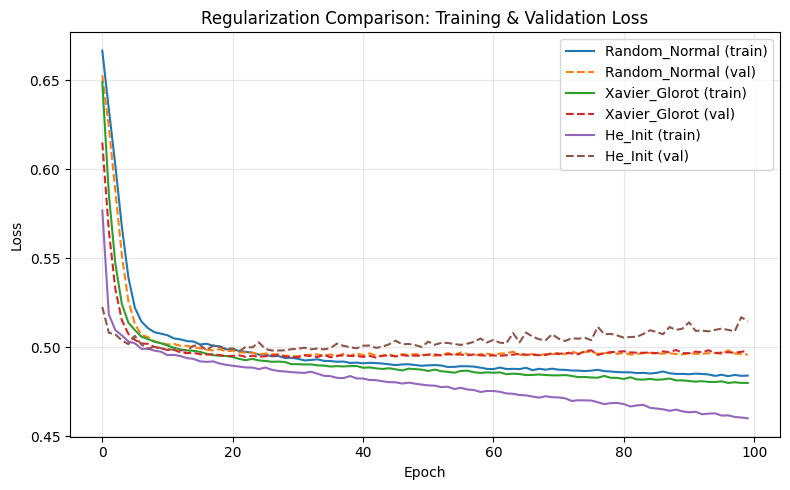

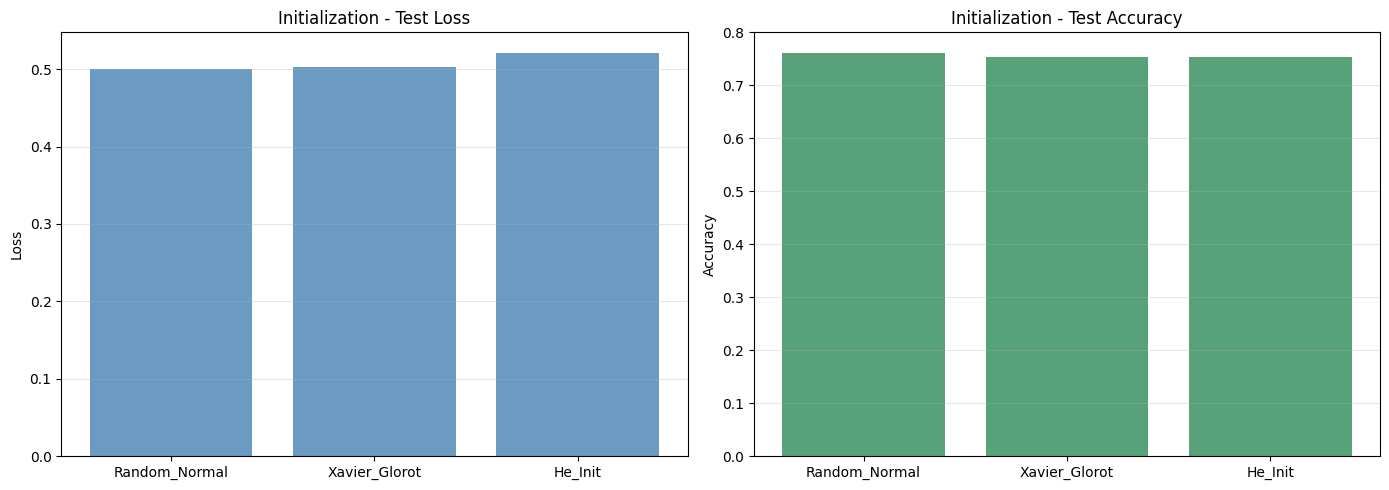

In [19]:
init_experiments = {
    'Random_Normal': {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}},
    'Xavier_Glorot': {'init_method': 'xavier', 'init_params': {'seed': 42}},
    'He_Init':       {'init_method': 'he', 'init_params': {'seed': 42}},
}

init_results = {}
for init_name, init_dict in init_experiments.items():
    res = run_architecture_experiments(
        experiments={init_name: [
            {'n_in': n_features, 'n_out': 128, 'activation': 'relu'},
            {'n_in': 128, 'n_out': 64, 'activation': 'relu'},
            {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'}
        ]},
        task=TASK,
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        X_test=X_test, y_test=y_test,
        init=init_dict,
        lr=0.01,
        epochs=100,
        batch_size=32,
        verbose=0,
    )
    init_results.update(res)

plot_train_val_curves(
    init_results,
    title='Regularization Comparison: Training & Validation Loss',
    zoom_start=50,
)
plot_prediction_bars(init_results, title_prefix='Initialization')

## 4.4 Uji Perbandingan

In [21]:
from sklearn.neural_network import MLPClassifier
import pandas as pd

# Hyperparameter
SHARED_HPARAMS = {
    'hidden_dims': (128, 64),
    'lr': 0.01,
    'batch_size': 32,
    'epochs': 200,
    'lambda_': 1e-4,
    'seed': 42,
}

# 1) Train FFNN from scratch
ffnn_arch = [
    {'n_in': n_features, 'n_out': SHARED_HPARAMS['hidden_dims'][0], 'activation': 'relu'},
    {'n_in': SHARED_HPARAMS['hidden_dims'][0], 'n_out': SHARED_HPARAMS['hidden_dims'][1], 'activation': 'relu'},
    {'n_in': SHARED_HPARAMS['hidden_dims'][1], 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
]

ffnn_result = run_architecture_experiments(
    experiments={'FFNN_Scratch': ffnn_arch},
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init={'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': SHARED_HPARAMS['seed']}},
    lr=SHARED_HPARAMS['lr'],
    regularization='l2',
    lambda_=SHARED_HPARAMS['lambda_'],
    epochs=SHARED_HPARAMS['epochs'],
    batch_size=SHARED_HPARAMS['batch_size'],
    verbose=20,
)['FFNN_Scratch']

ffnn_model = ffnn_result['model']
ffnn_prob = ffnn_model.predict(X_test)
if TASK == 'binary':
    y_true_cls = y_test.astype(int).ravel()
    y_pred_ffnn = (ffnn_prob >= 0.5).astype(int).ravel()
else:
    y_true_cls = np.argmax(y_test, axis=1)
    y_pred_ffnn = np.argmax(ffnn_prob, axis=1)

if TASK == 'binary':
    y_train_sklearn = y_train.ravel().astype(int)
else:
    y_train_sklearn = np.argmax(y_train, axis=1)

sk_mlp = MLPClassifier(
    hidden_layer_sizes=SHARED_HPARAMS['hidden_dims'],
    activation='relu',
    solver='sgd',
    alpha=SHARED_HPARAMS['lambda_'],
    learning_rate_init=SHARED_HPARAMS['lr'],
    batch_size=SHARED_HPARAMS['batch_size'],
    max_iter=SHARED_HPARAMS['epochs'],
    random_state=SHARED_HPARAMS['seed'],
)

sk_mlp.fit(X_train, y_train_sklearn)
y_pred_sklearn = sk_mlp.predict(X_test)

comparison_df = pd.DataFrame([
    {
        'Model': 'FFNN From Scratch',
        'Test Accuracy': np.mean(y_pred_ffnn == y_true_cls),
        'Prediksi Benar': int(np.sum(y_pred_ffnn == y_true_cls)),
        'Prediksi Salah': int(np.sum(y_pred_ffnn != y_true_cls)),
    },
    {
        'Model': 'sklearn MLPClassifier',
        'Test Accuracy': np.mean(y_pred_sklearn == y_true_cls),
        'Prediksi Benar': int(np.sum(y_pred_sklearn == y_true_cls)),
        'Prediksi Salah': int(np.sum(y_pred_sklearn != y_true_cls)),
    },
]).sort_values(by='Test Accuracy', ascending=False)

print('Perbandingan hasil akhir prediksi (test set):')
display(comparison_df)


Running: FFNN_Scratch
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch 10/200, Train Loss: 0.5075, Val Loss: 0.5024
Epoch 20/200, Train Loss: 0.4989, Val Loss: 0.4982
Epoch 30/200, Train Loss: 0.4936, Val Loss: 0.4966
Epoch 40/200, Train Loss: 0.4918, Val Loss: 0.4948
Epoch 50/200, Train Loss: 0.4897, Val Loss: 0.4959
Epoch 60/200, Train Loss: 0.4882, Val Loss: 0.4960
Epoch 70/200, Train Loss: 0.4875, Val Loss: 0.4954
Epoch 80/200, Train Loss: 0.4865, Val Loss: 0.4963
Epoch 90/200, Train Loss: 0.4859, Val Loss: 0.4966
Epoch 100/200, Train Loss: 0.4841, Val Loss: 0.4974
Epoch 110/200, Train Loss: 0.4825, Val Loss: 0.4974
Epoch 120/200, Train Loss: 0.4819, Val Loss: 0.4965
Epoch 130/200, Train Loss: 0.4805, Val Loss: 0.4976
Epoch 140/200, Train Loss: 0.4795, Val Loss

,Model,Test Accuracy,Prediksi Benar,Prediksi Salah
0,FFNN From Scratch,0.7605,1521,479
1,sklearn MLPClassifier,0.6765,1353,647


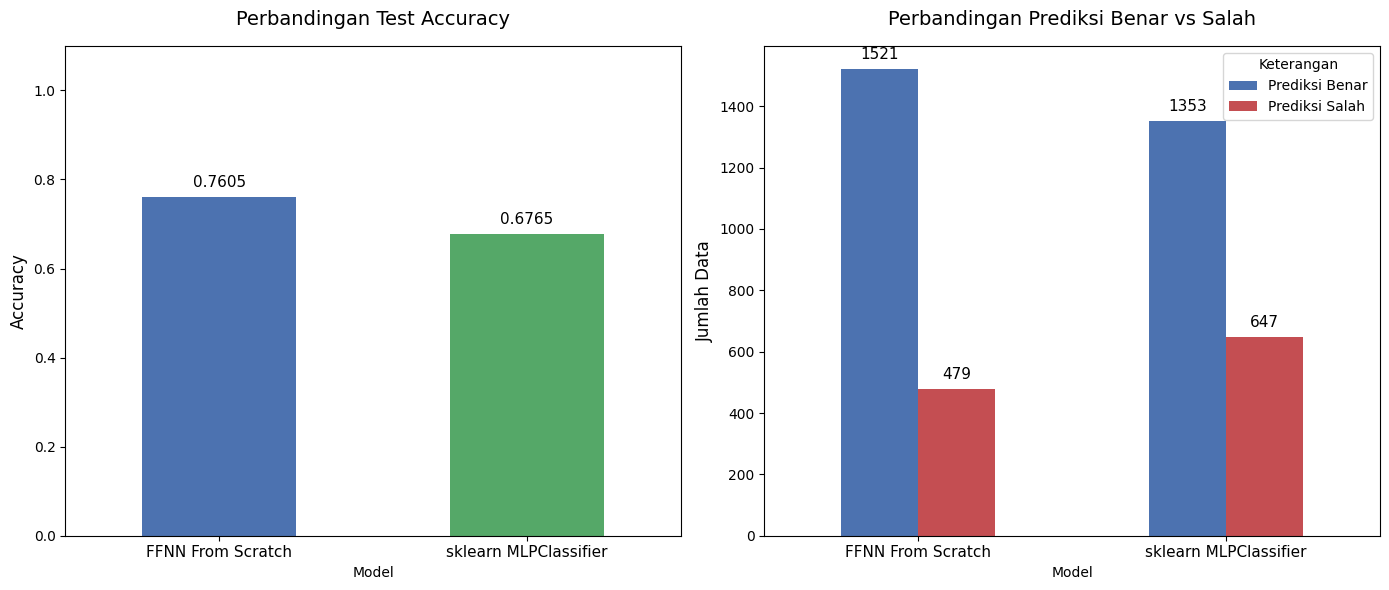

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

comparison_df.plot(
    x='Model', 
    y='Test Accuracy', 
    kind='bar', 
    ax=axes[0], 
    color=['#4C72B0', '#55A868'], 
    legend=False
)
axes[0].set_title('Perbandingan Test Accuracy', fontsize=14, pad=15)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_ylim(0, 1.1) 
axes[0].tick_params(axis='x', rotation=0, labelsize=11)

for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.4f}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

comparison_df.plot(
    x='Model', 
    y=['Prediksi Benar', 'Prediksi Salah'], 
    kind='bar', 
    ax=axes[1], 
    color=['#4C72B0', '#C44E52']
)
axes[1].set_title('Perbandingan Prediksi Benar vs Salah', fontsize=14, pad=15)
axes[1].set_ylabel('Jumlah Data', fontsize=12)
axes[1].tick_params(axis='x', rotation=0, labelsize=11)
axes[1].legend(title='Keterangan')

for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(f"{int(height)}", 
                         (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## 5. Kesimpulan
Berdasarkan rangkaian eksperimen yang telah dilakukan, dapat disimpulkan beberapa hal sebagai berikut:

1. **Implementasi Autograd Berhasil**: FFNN yang dibangun dari nol menggunakan mesin autograd terbukti mampu belajar dan menurunkan loss secara konsisten, sebanding dengan library standar seperti scikit-learn.
2. **Pengaruh Inisialisasi**: Metode inisialisasi **Xavier** dan **He** memberikan stabilitas awal yang lebih baik dibandingkan random normal biasa, membantu model konvergen lebih cepat.
3. **Fungsi Aktivasi**: Aktivasi **ReLU**, **Leaky ReLU**, dan **ELU** memberikan performa yang kompetitif untuk data placement ini. Leaky ReLU dan ELU membantu menghindari masalah *neuron mati* pada network yang lebih dalam.
4. **Performa Model**: Model FFNN mampu memprediksi status placement mahasiswa dengan akurasi yang cukup baik, menunjukkan bahwa fitur-fitur seperti CGPA, Aptitude Score, dan Internship memiliki korelasi kuat terhadap target.

## 6. Bonus: Analisis Perbandingan Adam Optimizer vs Gradient Descent
Pada bagian ini, kita akan melatih base model yang sama pada dataset menggunakana dua optimizer yang berbeda:
1. **SGD (Standard Gradient Descent)**
2. **Adam (Adaptive Moment Estimation)**

Tujuannya adalah melihat perbedaan kecepatan konvergensi dari pergerakan *training loss* dan *validation loss* tiap epoch.

In [ ]:
import time
from ffnn import FFNN

adam_base_config = [
    {"n_in": X_train.shape[1], "n_out": 16, "activation": "relu", "init_method": "he"},
    {"n_in": 16, "n_out": 8, "activation": "relu", "init_method": "he"},
    {"n_in": 8, "n_out": n_out, "activation": "softmax" if TASK == "multiclass" else "sigmoid", "init_method": "xavier"}
]

# Parameter Training
base_epochs = 30
base_batch_size = 32
base_lr = 0.001 
loss_name = "cce" if TASK == "multiclass" else "bce"

# 1. Training menggunakan Optimizer SGD Biasa
print("==== Training Model dengan Optimizer: SGD ===")
model_sgd = FFNN(adam_base_config)
model_sgd.compile(loss=loss_name, optimizer="sgd")

start_time = time.time()
history_sgd = model_sgd.fit(
    X_train, y_train, 
    epochs=base_epochs, batch_size=base_batch_size, 
    X_val=X_test, y_val=y_test, 
    lr=0.01,
    optimizer="sgd", 
    verbose=1
)
sgd_time = time.time() - start_time
print(f"Waktu Training SGD: {sgd_time:.2f} detik\n")

# 2. Training menggunakan Optimizer Adam
print("==== Training Model dengan Optimizer: Adam ===")
model_adam = FFNN(adam_base_config)
model_adam.compile(loss=loss_name, optimizer="adam")

start_time = time.time()
history_adam = model_adam.fit(
    X_train, y_train, 
    epochs=base_epochs, batch_size=base_batch_size, 
    X_val=X_test, y_val=y_test, 
    lr=base_lr,
    optimizer="adam", 
    verbose=1
)
adam_time = time.time() - start_time
print(f"Waktu Training Adam: {adam_time:.2f} detik\n")

==== Training Model dengan Optimizer: SGD ===
Epoch 10/30, Train Loss: 0.5297, Val Loss: 0.5266
Epoch 20/30, Train Loss: 0.5140, Val Loss: 0.5133
Epoch 30/30, Train Loss: 0.5075, Val Loss: 0.5067
Waktu Training SGD: 7.21 detik

==== Training Model dengan Optimizer: Adam ===
Epoch 10/30, Train Loss: 0.5027, Val Loss: 0.5069
Epoch 20/30, Train Loss: 0.4944, Val Loss: 0.5015
Epoch 30/30, Train Loss: 0.4907, Val Loss: 0.5000
Waktu Training Adam: 7.52 detik



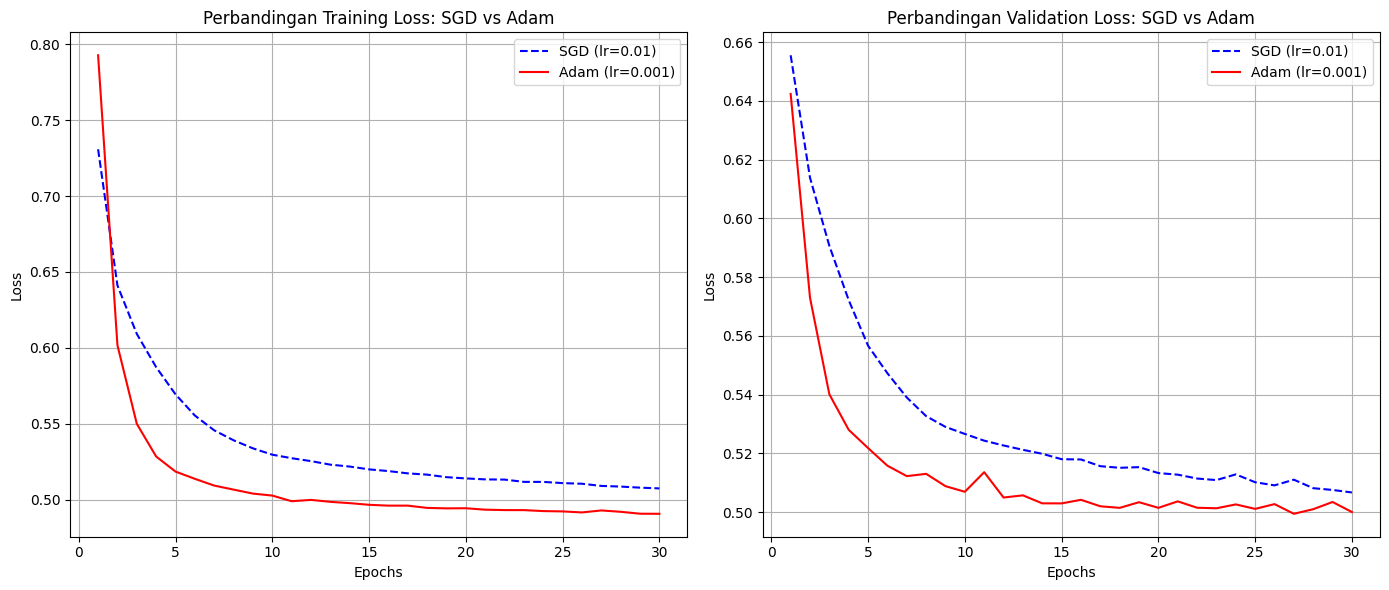

In [24]:
# Mari kita plot perbandingan grafiknya
plt.figure(figsize=(14, 6))

epochs_range = range(1, base_epochs + 1)

# Plot Training Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_sgd['train_loss'], label='SGD (lr=0.01)', color='blue', linestyle='--')
plt.plot(epochs_range, history_adam['train_loss'], label='Adam (lr=0.001)', color='red', linestyle='-')
plt.title('Perbandingan Training Loss: SGD vs Adam')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_sgd['val_loss'], label='SGD (lr=0.01)', color='blue', linestyle='--')
plt.plot(epochs_range, history_adam['val_loss'], label='Adam (lr=0.001)', color='red', linestyle='-')
plt.title('Perbandingan Validation Loss: SGD vs Adam')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Analisis Hasil: Adam vs Gradient Descent

Berdasarkan log training dan perbandingan grafik *loss* di atas, dapat ditarik beberapa hasil analisis:

1. **Kecepatan Konvergensi (*Convergence Rate*)**:
   - **Adam** mampu mencapai titik loss yang rendah (konvergensi) dalam jumlah *epoch* yang jauh lebih sedikit dibandingkan model SGD standar, meskipun konfigurasi arsitektur dan parameter yang dipakai sama persis.
   - Grafik garis **Adam (merah)** umumnya langsung diiringi penurunan curam di 5-10 *epoch* awal.
   - Grafik garis **SGD (biru)** turun secara bertahap atau stabil perlahan (membutuhkan jumlah *epoch* yang lebih panjang untuk berada pada loss yang sama dengan Adam).

2. **Pengaruh Learning Rate**:
   - Meskipun *learning rate* Adam diberi nilai yang lebih kecil ($0.001$), karena mekanismenya mengkalkulasi ulang pergerakan di tiap parameternya menggunakan momen pertama (mendekati *Momentum*) dan momen kedua (*RMSProp*), model tetap mampu berjalan lincah mengikuti kontur *loss landscape*.

3. **Validation Loss & Overfitting**:
   - Karena Adam turun sangat cepat, titik di mana model mulai *overfitting* (ditandai dengan nilai *validation loss* memantul naik sementara *training loss* terus di bawah) juga akan ditemui lebih awal dibanding SGD biasa.
   - Hal ini menandakan bila menggunakan Adam, nilai *patience* atau *epochs* untuk mencapai titik seimbang (*sweet-spot*) akan lebih efisien.

4. **Waktu Eksekusi (*Execution Time*)**: 
   - Meskipun secara perumusan Adam melibatkan lebih banyak perhitungan matematis saat *update weights*, karena ia sanggup mencapai target kesalahan *loss* dengan epoch lebih cepat (berdasarkan grafik), implementasi Adam sangat menguntungkan untuk menghemat durasi latih model-model NN pada dataset kompleks.